# Rare Object Detection — Embedding Evaluation & Active Learning

This notebook evaluates the quality of learned embeddings across training runs that vary several hyperparameters:
- **Label fraction `f`**: fraction of the training set that carries morphological labels (0 = fully unsupervised, 1 = fully labelled)
- **Supervision weight `sw`**: relative weight of the supervised contrastive loss term
- **`vicregvar`**, **`cov`**, **`gamma`**: VICReg loss coefficients (variance, covariance, and EMA-target gamma)

Retrieval quality is measured with **nDCG@10** per morphological class. The second half of the notebook runs **Protege** Gaussian-Process active learning on the resulting embeddings to efficiently surface rare/interesting radio galaxies.

All dependencies are installed and imported in the first code cell.

In [1]:
import re
import subprocess
import sys
import torch

# Install dependencies only if missing
def _install(*packages):    
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

try:
    import astronomaly
except ModuleNotFoundError:
    _install("git+https://github.com/MichelleLochner/astronomaly.git")

try:
    import pyarrow
except ModuleNotFoundError:
    _install("pyarrow", "fastparquet", "numpy<2")

try:
    import ipywidgets as widgets
except ModuleNotFoundError:
    _install("ipywidgets")
    import ipywidgets as widgets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path as MPath
from pathlib import Path
from collections import defaultdict
from scipy.spatial.distance import cdist
import json
import hashlib

import astronomaly
from astronomaly.anomaly_detection import protege, human_loop_learning
from astronomaly.feature_extraction import shape_features as _sf
from astronomaly.base.base_dataset import Dataset as _AstroDataset

# Add src/ to path so suplat is importable regardless of which kernel is active
sys.path.insert(0, "/users/mbredber/p3_SUPLAT/src")
from suplat.models.byol_models import BYOLEfficientNetB0, BYOLEfficient

import umap as umap_lib
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest as _IsoForest
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

from IPython.display import display, clear_output

print("astronomaly version:", astronomaly.__version__)
print("numpy version:", np.__version__)
print("pyarrow version:", pyarrow.__version__)

%matplotlib inline

astronomaly version: 2.0
numpy version: 1.26.4
pyarrow version: 14.0.2


## Configuration

Set top-level paths, glob patterns, and evaluation parameters used throughout the notebook. Adjust `OUTPUTS_ROOT`, `RUN_GLOB`, and the data paths to match your local setup.

In [2]:
# ── Config ───────────────────────────────────────────────────────────────────
OUTPUTS_ROOT   = Path("/users/mbredber/p3_SUPLAT/outputs")
BYOL_RUNS_ROOT = OUTPUTS_ROOT / "byol_runs"
RUN_GLOB       = "enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_*_f*_sw*_*"
EVAL_SPLIT     = "test"    # split used for nDCG evaluation
N_CLASSES      = 20        # number of label dimensions
NDCG_K         = 10        # k in nDCG@k

CSV_PATH        = "/users/mbredber/p3_SUPLAT/data/metadata/lotss_classifications_horton_et_al_2025_filtered.csv"
CUTOUT_DIR      = "/users/mbredber/p3_SUPLAT/data/raw/lotss_cutouts"
LABELS_NPY_PATH = "/users/mbredber/p3_SUPLAT/data/preprocessed/lotss/labels_filtered.npy"
IMAGES_PATH     = "/users/mbredber/p3_SUPLAT/data/preprocessed/lotss/images_filtered.npy"

# ── Protege run selection ─────────────────────────────────────────────────────
F_LABEL            = 1     # label fraction of the run to analyse
SUPERVISION_WEIGHT = 0.05  # supervision weight of the run to analyse
RUN_NAME_FILTER    = "20260709_2203"   # optional substring to disambiguate (e.g. "extaug", "ed996"); leave "" to pick latest

_run_glob_specific = RUN_GLOB.replace("f*_sw*", f"f{F_LABEL}_sw{SUPERVISION_WEIGHT}")
_matching = sorted(BYOL_RUNS_ROOT.glob(_run_glob_specific))
if RUN_NAME_FILTER:
    _matching = [r for r in _matching if RUN_NAME_FILTER in r.name]
assert len(_matching) >= 1, (
    f"No runs found matching f={F_LABEL} sw={SUPERVISION_WEIGHT} filter={RUN_NAME_FILTER!r}"
)
if len(_matching) > 1:
    print(f"Warning: {len(_matching)} runs match — using the latest:")
    for r in _matching:
        print(f"  {r.name}")
_run_dir = _matching[-1]   # latest by sorted name (date suffix)
RUN_DIR = str(_run_dir / "data")
print(f"RUN_DIR: {RUN_DIR}")

# ── Protege active-learning hyperparameters ───────────────────────────────────
USE_ENCODINGS = True  # If True, load encodings instead of projections for the GP pipeline
APPLY_PCA = True      # Whether to apply PCA before Protege; set to False to use original features

# Tag encoding latent-space type + PCA choice — used in file/figure names
_latent_tag = ("enc" if USE_ENCODINGS else "proj") + ("_pca" if APPLY_PCA else "")
INITIAL_STEPS  = 200   # initial evenly-spaced seed labels (only used when running from scratch)
STEPS_PER_ITER = 100   # labels acquired per GP iteration (matches --steps in train_byol_proteges.py)
EPSILON        = 2    # Higher ε means more exploration, lower ε means more exploitation. Paper default is 2. Set to 0 to disable exploration and run pure exploitation (greedy acquisition of top-uncertainty samples).


RUN_DIR: /users/mbredber/p3_SUPLAT/outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/data


## Retrieval Metric: nDCG@10

`nDCGk_avg` computes the mean nDCG@10 score for a given morphological class by treating every member of that class as a query in turn, ranking the remaining embeddings by cosine similarity, and scoring the ranked list against ground-truth labels. A score of 1.0 means all top-10 nearest neighbours belong to the correct class; 0.0 means none do.

In [3]:
def get_relevance(proj_in, lab_in, ref_class, mode="uniform"):
    relevance = np.zeros((proj_in.shape[0],))
    relevance[lab_in[:,ref_class]==True] = 1
    return relevance

def DCG(relevance_descending, k=10):
    num = 2**relevance_descending[:k] - 1
    den = np.log2(1+np.arange(1,k+1))
    return (num/den).sum()

def nDCG(relevance, sorting_cossim, k=10):
    IDCGk = DCG(np.sort(relevance)[::-1], k=k)
    DCGk = DCG(relevance[sorting_cossim], k=k)
    return DCGk/IDCGk

def nDCGk_avg(proj_in, lab_in, ref_class, k=20):
    mask_class = (lab_in[:,ref_class]==True)
    res = []
    for idx_ref in range(mask_class.sum()):
        reference_proj = proj_in[(lab_in[:,ref_class]==True)][idx_ref]
        mask_ref = (np.arange(proj_in.shape[0])==np.argwhere((lab_in[:,ref_class]==True))[idx_ref])
        proj_search = proj_in[~mask_ref]
        cos_d  = cdist(reference_proj[None,:], proj_search,   metric='cosine')
        sorting_cossim = np.argsort(cos_d.squeeze())
        relevance = get_relevance(proj_search, lab_in[~mask_ref], ref_class)
        nDCG_samp = nDCG(relevance, sorting_cossim, k=k)
        res.append(nDCG_samp)
    return (np.asarray(res).mean())

def nDCGk_avg_fast(proj_norm, lab_in, ref_class, k=20):
    """Vectorized nDCG@k. proj_norm must be L2-normalised (call once per run).
    Computes all query similarities in a single matrix multiply instead of
    one cdist call per class member."""
    mask      = lab_in[:, ref_class].astype(bool)
    class_idx = np.where(mask)[0]
    n_class   = len(class_idx)
    if n_class == 0:
        return np.nan

    # (n_class, N) cosine similarity via matmul; exclude self
    sim = proj_norm[class_idx] @ proj_norm.T          # (n_class, N)
    sim[np.arange(n_class), class_idx] = -np.inf

    # Relevance in ranked order for each query
    order      = np.argsort(-sim, axis=1)             # (n_class, N)
    rel_ranked = mask[order][:, :k].astype(float)     # (n_class, k)

    # DCG per query
    discount = 1.0 / np.log2(np.arange(2, k + 2))    # rank 1..k
    dcg      = (rel_ranked * discount).sum(axis=1)    # (n_class,)

    # IDCG is the same for every query: min(k, n_class-1) hits at top ranks
    n_rel = min(k, n_class - 1)
    idcg  = discount[:n_rel].sum() if n_rel > 0 else 0.0

    if idcg == 0:
        return 0.0
    return float((dcg / idcg).mean())

## Multi-Run Comparison

Loads test embeddings from every run directory matching `RUN_GLOB` (a string or list of glob patterns), computes per-class nDCG@10 for each, and collects the results into `run_results` for plotting.

In [4]:
# Derive a glob that matches only runs in the same "family" as _run_dir
# (same hyperparams, any f/sw value, any timestamp)
_family_glob = re.sub(r'_f[\d.]+_sw[\d.]+', '_f*_sw*', _run_dir.name)
_family_glob = re.sub(r'_\d{8}_\d{4}$', '_*', _family_glob)
run_dirs = sorted(BYOL_RUNS_ROOT.glob(_family_glob))
print(f"Family glob: {_family_glob}")
print(f"Found {len(run_dirs)} runs in family.")

def _ndcg_data_seed(rd):
    ckpt = torch.load(rd / "byol_model_best.pt", map_location="cpu", weights_only=False)
    return int(ckpt["config"]["data_seed"])

run_results = []
for rd in run_dirs:
    m = re.search(r'_f([\d.]+)_sw([\d.]+)_', rd.name)
    if not m:
        continue
    f_val  = float(m.group(1))
    sw_val = float(m.group(2))

    byol_dir  = rd / "data" / "byol"
    proj_path = byol_dir / f"{EVAL_SPLIT}_projections.npy"
    if not proj_path.exists():
        # fallback for old runs
        proj_path = rd / "data" / f"{EVAL_SPLIT}_projections.npy"
    if not proj_path.exists():
        print(f"  skipping {rd.name}  (missing {EVAL_SPLIT} projections)")
        continue

    # labels are saved in the shared data_splits dir
    try:
        _ds = _ndcg_data_seed(rd)
    except Exception:
        _ds = 42
    labels_path = OUTPUTS_ROOT / "data_splits" / str(_ds) / f"{EVAL_SPLIT}_labels.npy"
    if not labels_path.exists():
        print(f"  skipping {rd.name}  (missing labels at {labels_path})")
        continue

    proj   = np.load(proj_path)
    labels = np.load(labels_path)
    # L2-normalise once; nDCGk_avg_fast uses a single matmul per class
    norms     = np.linalg.norm(proj, axis=1, keepdims=True)
    proj_norm = proj / np.maximum(norms, 1e-10)
    ndcg = [nDCGk_avg_fast(proj_norm, labels, c, k=NDCG_K) for c in range(N_CLASSES)]
    run_results.append(dict(name=rd.name, f=f_val, sw=sw_val, ndcg=ndcg))
    print(f"  loaded {rd.name}  (f={f_val}, sw={sw_val})")

print(f"\nLoaded {len(run_results)} runs.")

Family glob: enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f*_sw*_augquart_ext_*
Found 18 runs in family.
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0.1_sw0.05_augquart_ext_20260720_1528  (f=0.1, sw=0.05)


  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0.1_sw3_augquart_ext_20260714_1550  (f=0.1, sw=3.0)
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0.5_sw0.05_augquart_ext_20260720_1619  (f=0.5, sw=0.05)
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0.5_sw3_augquart_ext_20260714_1636  (f=0.5, sw=3.0)
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0_sw0.0_augquart_ext_20260720_1709  (f=0.0, sw=0.0)
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203  (f=1.0, sw=0.05)
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.0_augquart_ext_20260709_2117  (f=1.0, sw=0.0)
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.5_augquart_ext_20260709_2253  (f=1.0, sw=0.5)
  loaded enb0_

### nDCG@10 Results Plot

Each point is one (run, class) pair. **Colour** encodes `sw` on a log-scaled viridis gradient (dark = low, bright = high). **Filled fraction of the circle** encodes `f`: an empty circle means no labels were used; a fully filled circle means all labels were used.

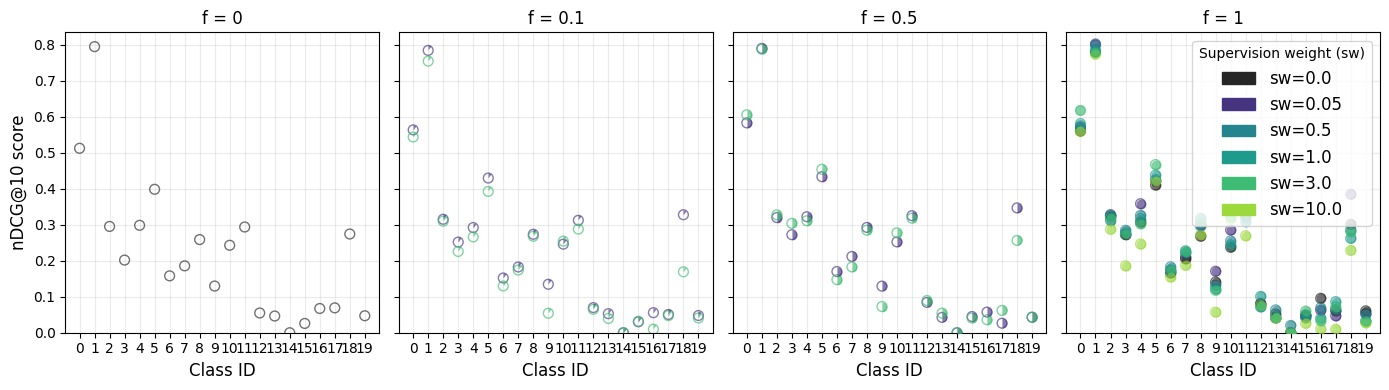

In [5]:
def pie_marker(fraction):
    """Wedge Path covering `fraction` of the unit circle, clockwise from 12 o'clock."""
    if fraction >= 1.0:
        n = 100
        t = np.linspace(0, 2 * np.pi, n, endpoint=False)
        verts = np.column_stack([np.cos(t), np.sin(t)])
        codes = [MPath.MOVETO] + [MPath.LINETO] * (n - 1) + [MPath.CLOSEPOLY]
        return MPath(np.vstack([verts, verts[:1]]), codes)
    n = 50
    t = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi * fraction, n)
    verts = [(0.0, 0.0)] + list(zip(np.cos(t), np.sin(t))) + [(0.0, 0.0)]
    codes = [MPath.MOVETO] + [MPath.LINETO] * n + [MPath.CLOSEPOLY]
    return MPath(verts, codes)


f_vals  = sorted(set(r['f']  for r in run_results))
sw_vals = sorted(set(r['sw'] for r in run_results))

if not run_results:
    print("No run results found — skipping nDCG plot.")
else:
    cmap = plt.cm.viridis
    # Log-normalise only non-zero sw values; sw=0 gets a distinct dark colour
    _sw_nonzero = [sw for sw in sw_vals if sw > 0]
    if len(_sw_nonzero) > 1:
        _log = np.log10(_sw_nonzero)
        _norm = (_log - _log.min()) / (_log.max() - _log.min())
    else:
        _norm = [0.5] * len(_sw_nonzero)
    sw_color = {sw: cmap(0.15 + 0.70 * v) for sw, v in zip(_sw_nonzero, _norm)}
    if 0.0 in sw_vals:
        sw_color[0.0] = (0.15, 0.15, 0.15, 1.0)  # near-black for unsupervised

    _fig_dir = OUTPUTS_ROOT / "figures" / "protege"
    _fig_dir.mkdir(parents=True, exist_ok=True)

    S, ALPHA = 50, 0.65
    LFS = 12

    ncols = len(f_vals)
    fig, axes = plt.subplots(1, ncols, figsize=(3.5 * ncols, 4), sharey=True)
    if ncols == 1:
        axes = [axes]

    x = np.arange(N_CLASSES)

    for ax, f_val in zip(axes, f_vals):
        runs_f = [r for r in run_results if r['f'] == f_val]

        for r in runs_f:
            color = sw_color[r['sw']]
            ax.scatter(x, r['ndcg'], facecolors='none', edgecolors=[color] * N_CLASSES,
                       marker='o', s=S, linewidths=1.0, zorder=2, alpha=ALPHA)
            if f_val > 0:
                ax.scatter(x, r['ndcg'], color=color, marker=pie_marker(f_val),
                           s=S, linewidths=0, zorder=3, alpha=ALPHA)

        ax.set_xlabel("Class ID", fontsize=12)
        ax.set_title(f"f = {f_val:g}", fontsize=12)
        ax.set_ylim([0, None])
        ax.set_xticks(x)
        ax.tick_params(labelsize=10)
        ax.grid(True, alpha=0.25)

    axes[0].set_ylabel("nDCG@10 score", fontsize=12)

    sw_handles = [
        mpatches.Patch(color=sw_color[sw], label=f'sw={sw}')
        for sw in sw_vals
    ]
    axes[-1].legend(handles=sw_handles, title='Supervision weight (sw)',
                    loc='upper right', framealpha=0.8, fontsize=LFS)

    plt.tight_layout()
    fig.savefig(_fig_dir / "ndcg_overview.png", dpi=150, bbox_inches="tight")
    plt.show()

## Class Index Mapping

Based on the LoTSS classifications (Horton et al. 2025), the 20-dimensional
label vector corresponds to the following classes:

| Index | Column          | Classification       | Type        | N sources |
|-------|-----------------|----------------------|-------------|-----------|
| 0     | `fri`           | FRI                  | Initial     | 2992      |
| 1     | `frii`          | FRII                 | Initial     | 6231      |
| 2     | `hybrid`        | Hybrids              | Initial     | 966       |
| 3     | `spiral`        | Spirals              | Initial     | 234       |
| 4     | `relaxed`       | Relaxed doubles      | Initial     | 440       |
| 5     | `cshaped`       | C-curvature          | Morphology  | 2379      |
| 6     | `sshaped`       | S-curvature          | Morphology  | 1082      |
| 7     | `misaligned`    | Misalignment         | Morphology  | 1287      |
| 8     | `wings`         | Wings                | Morphology  | 1564      |
| 9     | `xshaped`       | X-shaped             | Morphology  | 179       |
| 10    | `straight`      | Straight jets        | Morphology  | 358       |
| 11    | `multihotspots` | Multiple hotspots    | Morphology  | 2040      |
| 12    | `continuous`    | Continuous jets      | Morphology  | 337       |
| 13    | `banding`       | Banding              | Morphology  | 133       |
| 14    | `onesided`      | One-sided            | Morphology  | 23        |
| 15    | `restarted`     | Restarted            | Morphology  | 193       |
| 16    | `cluster`       | Cluster              | Environment | 72        |
| 17    | `merger`        | Merger               | Environment | 63        |
| 18    | `diffuse`       | Diffuse emission     | Environment | 111       |
| 19    | `unknown`       | Unknown              | Environment | 126       |

### Protege interest scoring

Each source is assigned the score of its most interesting label (multi-label sources take the highest applicable score).
Counts are from the full 7596-row dataset (`labels_filtered.npy`), before any train/val/test split.
Positives (score ≥ 3): **1303** (17.2%).

| Score | Label(s) | Count | % |
|-------|----------|-------|---|
| 4 | `xshaped`, `unknown`, `cluster`, `merger` | 285 | 3.8% |
| 3 | `diffuse`, `sshaped`, `spiral` | 1018 | 13.4% |
| 2 | `restarted`, `onesided`, `banding`, `cshaped`, `wings`, `misaligned`, `multihotspots`, `relaxed` | 3480 | 45.8% |
| 1 | `fri`, `frii`, `hybrid`, `straight`, `continuous`, (none of the above) | 2813 | 37.0% |
| **Total** | | **7596** | **100%** |

In [6]:
LABEL_COLS = [
    "fri", "frii", "hybrid", "spiral", "relaxed",
    "cshaped", "sshaped", "misaligned", "wings", "xshaped",
    "straight", "multihotspots", "continuous", "banding", "onesided",
    "restarted", "cluster", "merger", "diffuse", "unknown",
]  # must match the column order used when labels_filtered.npy was saved

SCORE_4 = ["xshaped", "unknown", "cluster", "merger"]
SCORE_3 = ["diffuse", "sshaped", "spiral"]
SCORE_2 = ["restarted", "onesided", "banding", "cshaped", "wings", "misaligned", "multihotspots", "relaxed"]
SCORE_1 = ["fri", "frii", "hybrid", "straight", "continuous"]

POSITIVE_THRESHOLD = 3     # sources with human_label >= this are "interesting"

### Average nDCG@10 by Interest Score

Groups the 20 morphological classes into four interest tiers (1 = common, 4 = rarest) and computes the mean nDCG@10 within each tier across all `(f, sw)` combinations, giving a compact view of retrieval quality per rarity level.

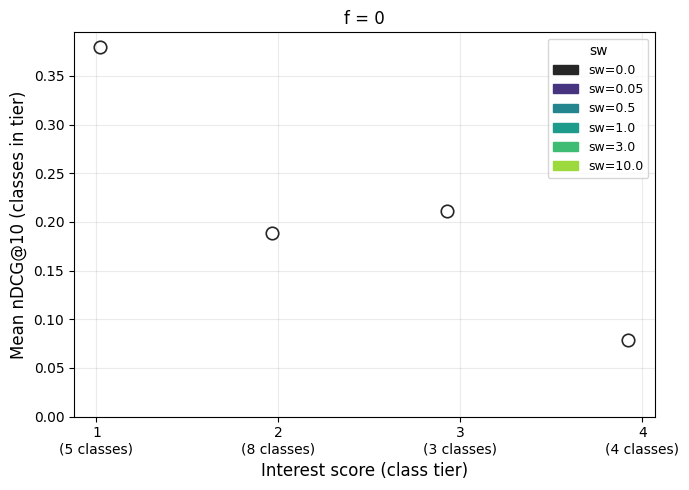

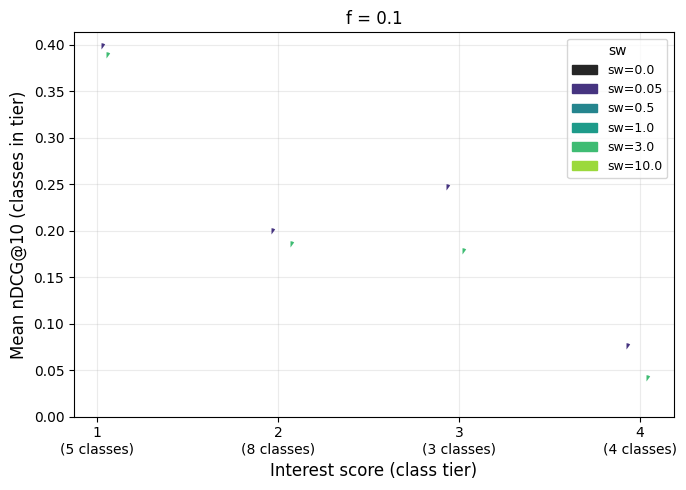

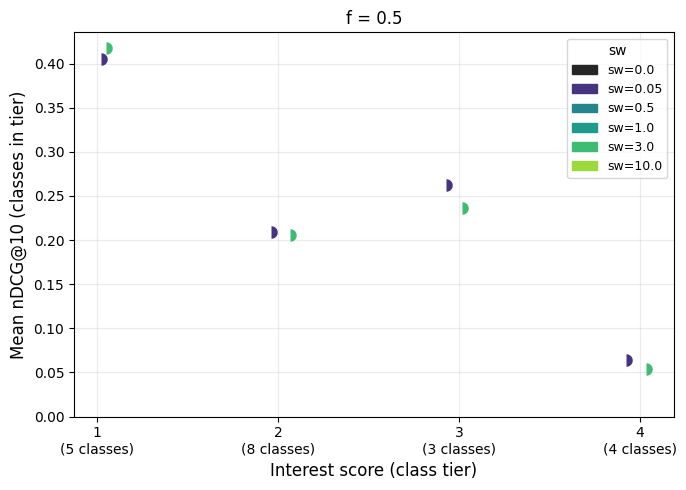

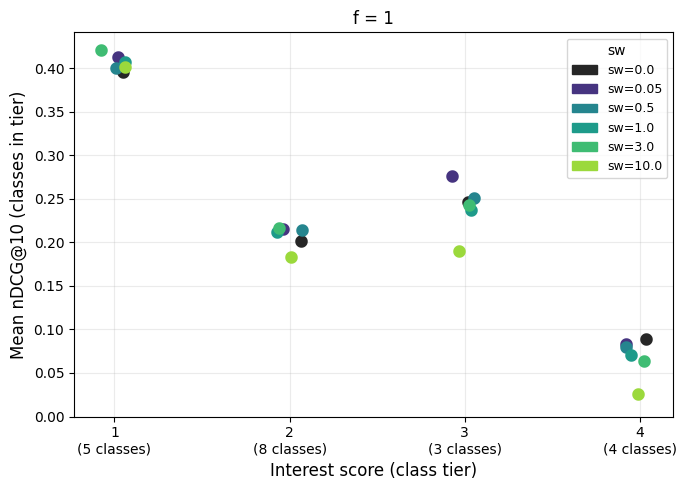

In [7]:
# ── Average nDCG@10 by interest score and (f, sw) combination ────────────────

# Map class index → interest score using the same tier definitions as Protege config
_LABEL_COLS = [
    "fri", "frii", "hybrid", "spiral", "relaxed",
    "cshaped", "sshaped", "misaligned", "wings", "xshaped",
    "straight", "multihotspots", "continuous", "banding", "onesided",
    "restarted", "cluster", "merger", "diffuse", "unknown",
]
_SCORE_MAP = {col: 1 for col in _LABEL_COLS}
for col in ["xshaped", "unknown", "cluster", "merger"]:
    _SCORE_MAP[col] = 4
for col in ["diffuse", "sshaped", "spiral"]:
    _SCORE_MAP[col] = 3
for col in ["restarted", "onesided", "banding", "cshaped", "wings", "misaligned", "multihotspots", "relaxed"]:
    _SCORE_MAP[col] = 2
_class_interest = np.array([_SCORE_MAP[c] for c in _LABEL_COLS])

interest_scores = sorted(set(_class_interest))
is_indices = {s: np.where(_class_interest == s)[0] for s in interest_scores}

_fig_dir = OUTPUTS_ROOT / "figures" / "protege"
_fig_dir.mkdir(parents=True, exist_ok=True)

runs_by_f = {}
for r in run_results:
    runs_by_f.setdefault(r['f'], []).append(r)

for f_val in sorted(runs_by_f):
    runs_f  = runs_by_f[f_val]
    marker  = pie_marker(f_val) if f_val > 0 else 'o'
    rng_jitter = np.random.default_rng(0)

    fig, ax = plt.subplots(figsize=(7, 5))

    for r in runs_f:
        c = sw_color[r['sw']]
        mkw = dict(markerfacecolor='none', markeredgecolor=c, markeredgewidth=1.2) if f_val == 0 \
              else dict(markerfacecolor=c, markeredgecolor='none')
        for score in interest_scores:
            idxs = is_indices[score]
            vals = [r['ndcg'][i] for i in idxs if not np.isnan(r['ndcg'][i])]
            if not vals:
                continue
            y = np.mean(vals)
            jitter = rng_jitter.uniform(-0.08, 0.08)
            ax.plot(score + jitter, y, marker=marker, markersize=9,
                    linestyle='none', zorder=3, **mkw)

    sw_handles = [mpatches.Patch(color=sw_color[sw], label=f'sw={sw}') for sw in sw_vals]
    ax.legend(handles=sw_handles, title='sw', loc='upper right', fontsize=9, framealpha=0.8)

    xtick_labels = [f'{s}\n({len(is_indices[s])} classes)' for s in interest_scores]
    ax.set_xticks(interest_scores)
    ax.set_xticklabels(xtick_labels, fontsize=10)
    ax.set_xlabel('Interest score (class tier)', fontsize=12)
    ax.set_ylabel('Mean nDCG@10 (classes in tier)', fontsize=12)
    ax.set_title(f"f = {f_val:g}", fontsize=12)
    ax.grid(True, alpha=0.25)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    fig.savefig(_fig_dir / f"ndcg_by_interest_score_f{f_val:g}.png", dpi=150, bbox_inches="tight")
    plt.show()


## Protege Active Learning Integration

Uses the [astronomaly](https://github.com/MichelleLochner/astronomaly) library to run a Gaussian-Process active learner on the learned embeddings. The GP iteratively selects the most informative unlabelled sources via an acquisition function, simulates a human labelling step using ground-truth morphology scores, and updates the model — surfacing rare/interesting sources far more efficiently than random inspection.

The GP is run in **transductive** mode: all sources (train + test) contribute to the kernel covariance, but only train sources can be queried. Final scores are predicted for all sources; test-set scores are used to evaluate recall.

Results from each single-run execution are persisted to `{RUN_DIR}/protege/` (i.e. `data/protege/` within the run directory) as `notebook_protege_{latent}_eps{EPSILON}_q{N_LABELS_TOTAL}.parquet`. The recall-curve cell automatically overlays all saved runs with different `EPSILON` values, so epsilon sweeps can be compared visually without re-running everything.

### Load Embeddings and Morphology Labels

Load the split's projection embeddings and positional row indices, join to the source catalogue CSV to recover `Source_Name` and per-class morphology flags, and convert the multi-label flags into a 1–5 human-interest score (5 = rarest/most exotic morphology).

In [8]:
RUN_DIR_ = Path(RUN_DIR)

# ── Derive shared splits directory ────────────────────────────────────────────
_run_dir_root = RUN_DIR_.parent   # RUN_DIR ends in /data, so parent = run dir
_ckpt_for_seed = torch.load(_run_dir_root / "byol_model_best.pt",
                             map_location="cpu", weights_only=False)
_data_seed_  = int(_ckpt_for_seed["config"]["data_seed"])
_splits_dir_ = _run_dir_root.parent.parent / "data_splits" / str(_data_seed_)

# Derive f-string matching the filename suffix used by train_byol.py
_f_label_ = _ckpt_for_seed["config"].get("f_label", F_LABEL)
_f_str_   = str(_f_label_).rstrip('0').rstrip('.') if '.' in str(_f_label_) else str(int(_f_label_))

def _load_idx_(name):
    """Load idx array: tries f-suffixed version first (new runs), then base name, then data_dir (old runs)."""
    stem, ext = name.rsplit('.', 1)
    p_fsuffix = _splits_dir_ / f"{stem}_f{_f_str_}.{ext}"
    p_base    = _splits_dir_ / name
    if p_fsuffix.exists():
        return np.load(p_fsuffix)
    elif p_base.exists():
        return np.load(p_base)
    else:
        return np.load(RUN_DIR_ / name)

# Feature files are in data/byol/ (new runs) or data/ (old runs)
_byol_dir_ = RUN_DIR_ / "byol" if (RUN_DIR_ / "byol").exists() else RUN_DIR_

# ── Load features + indices (handles f=0, f=1, and mixed 0<f<1) ─────────────
# USE_ENCODINGS selects encodings vs projections; both are saved by train_byol.py.
# For 0<f<1: labelled-only file; combine with unlabelled.
# For f=0: labelled file holds ALL train features (no unlabelled file).
# For f=1: all train sources are labelled — load from labelled files.
_feat_suffix     = "encodings" if USE_ENCODINGS else "projections"
_lab_proj        = np.load(_byol_dir_ / f"labelled_train_{_feat_suffix}.npy")
_lab_idx         = _load_idx_("labelled_train_idx.npy")
_unlab_idx       = _load_idx_("unlabelled_train_idx.npy")
_unlab_proj_path = _byol_dir_ / f"unlabelled_train_{_feat_suffix}.npy"

if _unlab_proj_path.exists() and len(_lab_idx) > 0 and len(_unlab_idx) > 0:
    _unlab_proj = np.load(_unlab_proj_path)
    projections = np.concatenate([_lab_proj, _unlab_proj], axis=0)
    idx_arr     = np.concatenate([_lab_idx, _unlab_idx])
elif len(_lab_idx) == 0:   # f=0: labelled_train_projections.npy contains all train projections
    projections = _lab_proj
    idx_arr     = _unlab_idx
else:                       # f=1: all sources are labelled
    projections = _lab_proj
    idx_arr     = _lab_idx

print(f"features ({_feat_suffix}): {projections.shape}  idx_arr: {idx_arr.shape}")
print(f"idx_arr max value: {idx_arr.max()}")
print(f"idx_arr min value: {idx_arr.min()}")
print(f"Any idx >= 7596 (npy length): {(idx_arr >= 7596).sum()}")

# Load CSV only for Source_Name — row order matches images_filtered.npy for the first 7596 rows
csv_df       = pd.read_csv(CSV_PATH)
source_names = csv_df.iloc[idx_arr]["Source_Name"].values

features_df = pd.DataFrame(projections, index=source_names)

# ── Load labels from the aligned .npy file (NOT the CSV) ──────────────────
# images_filtered.npy and labels_filtered.npy are row-aligned companions.
# The CSV has 7607 rows vs 7596 in the npy files — they are NOT aligned,
# so csv_df.iloc[idx_arr] gives wrong labels. Use labels_filtered.npy instead.

labels_all   = np.load(LABELS_NPY_PATH)       # shape (7596, 20)
labels_split = labels_all[idx_arr]            # shape (N_split, 20) — aligned with projections

# Build a DataFrame for convenient column access
labels_npy_df = pd.DataFrame(labels_split.astype(bool), columns=LABEL_COLS)

# Build human_label (1–4) from tier scoring
TIERS = [(4, SCORE_4), (3, SCORE_3), (2, SCORE_2)]
human_labels = np.ones(len(labels_npy_df), dtype=int)
for score_val, cols in reversed(TIERS):
    mask = labels_npy_df[cols].any(axis=1).values
    human_labels[mask] = score_val

labels_df = pd.DataFrame({"human_label": human_labels}, index=source_names)

print("human_label distribution:")
print(pd.Series(human_labels).value_counts().sort_index())
binary_label = (human_labels >= 4).astype(int)
print(f"\nPositives (score≥4): {binary_label.sum()}  |  Negatives: {(binary_label==0).sum()}")

# ── Load test projections + labels (needed for UMAP and Protege eval) ────────
_test_idx   = _load_idx_("test_idx.npy")
_test_proj  = np.load(_byol_dir_ / f"test_{_feat_suffix}.npy")

# Guard against drop_last truncation: test_projections may have fewer rows than test_idx
# (happens when the training script uses drop_last=True for the test loader)
_n_test = len(_test_proj)
if _n_test < len(_test_idx):
    print(f"  Warning: test_projections ({_n_test}) < test_idx ({len(_test_idx)}), trimming to match.")
    _test_idx = _test_idx[:_n_test]

_test_names = csv_df.iloc[_test_idx]["Source_Name"].values

_test_labels_raw = labels_all[_test_idx]
_test_labels_df  = pd.DataFrame(_test_labels_raw.astype(bool), columns=LABEL_COLS)
_test_human      = np.ones(len(_test_labels_df), dtype=int)
for _sv, _cols in reversed(TIERS):
    _test_human[_test_labels_df[_cols].any(axis=1).values] = _sv

labels_df = pd.concat([
    labels_df,
    pd.DataFrame({"human_label": _test_human}, index=_test_names),
])

# Combined train + test arrays (used by UMAP and PCA cells)
n_train   = len(projections)
all_proj  = np.concatenate([projections, _test_proj], axis=0)
all_names = np.concatenate([source_names, _test_names])

print(f"\nTest sources: {len(_test_idx)}  |  Total (train+test): {len(all_proj)}")

features (encodings): (5317, 1280)  idx_arr: (5317,)
idx_arr max value: 7595
idx_arr min value: 1
Any idx >= 7596 (npy length): 0
human_label distribution:
1    1959
2    2438
3     725
4     195
Name: count, dtype: int64

Positives (score≥4): 195  |  Negatives: 5122

Test sources: 2279  |  Total (train+test): 7596


### Image Gallery

Shows 5 example images per interest score (1–4) to give a visual intuition for what each tier looks like.

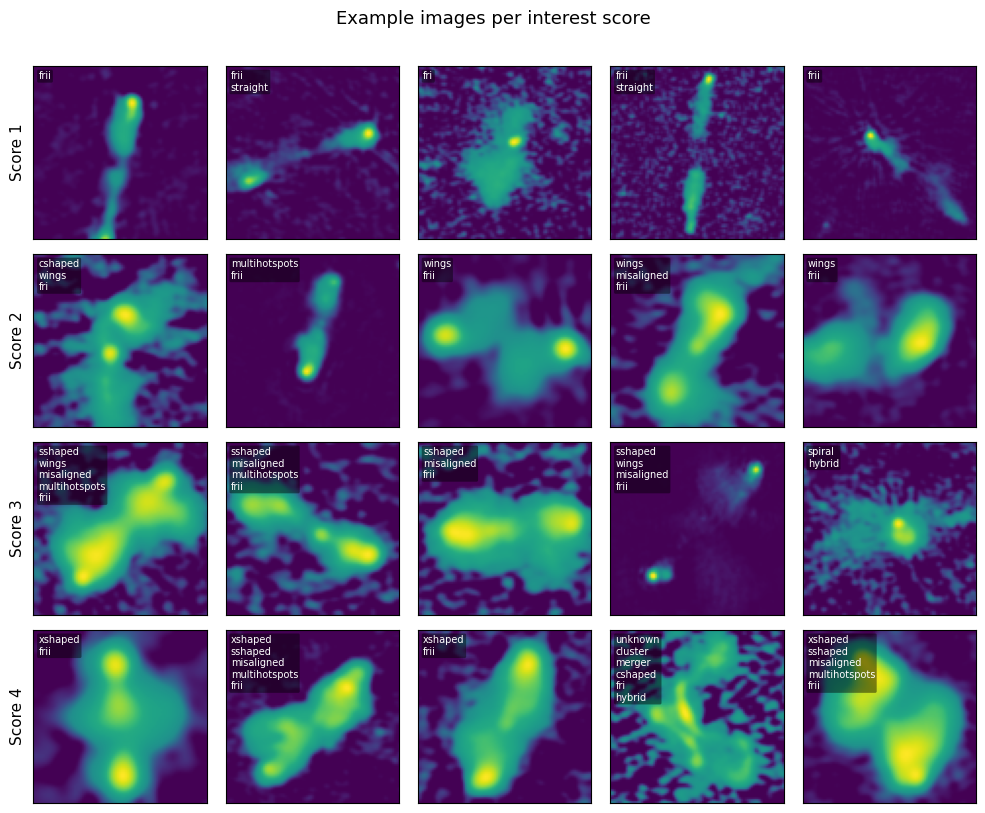

In [9]:
# Show 5 example images for each interest score (1–4)
images_all = np.load(IMAGES_PATH)
images = images_all[idx_arr]  # align with current split

ALL_MORPH_COLS = SCORE_4 + SCORE_3 + SCORE_2 + SCORE_1

N_EXAMPLES = 5
scores = [1, 2, 3, 4]
rng = np.random.default_rng(42)

fig, axes = plt.subplots(len(scores), N_EXAMPLES, figsize=(N_EXAMPLES * 2, len(scores) * 2))

for row, score in enumerate(scores):
    idxs = np.where(human_labels == score)[0]
    chosen = rng.choice(idxs, size=min(N_EXAMPLES, len(idxs)), replace=False)
    for col in range(N_EXAMPLES):
        ax = axes[row, col]
        if col < len(chosen):
            img = images[chosen[col]]
            if img.ndim == 3:
                img = img[0]  # take first channel if multi-channel
            ax.imshow(img, cmap='viridis', origin='lower')
            # Class labels: all True morphology columns for this source
            row_data = labels_npy_df.iloc[chosen[col]]
            active = [c for c in ALL_MORPH_COLS if row_data.get(c, False)]
            label_str = "\n".join(active) if active else "none"
            ax.text(0.03, 0.97, label_str, transform=ax.transAxes,
                    fontsize=7, color="white", va="top", ha="left",
                    bbox=dict(boxstyle="round,pad=0.15", fc="black", alpha=0.45, lw=0))
        else:
            ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(f"Score {score}", fontsize=11, labelpad=6)

fig.suptitle("Example images per interest score", fontsize=13, y=1.01)
plt.tight_layout()
_fig_dir = OUTPUTS_ROOT / "figures" / "protege"
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / "example_images_by_score.png", dpi=150, bbox_inches="tight")
plt.show()

### UMAP Projection

2-D UMAP of all sources (train + test), coloured by interest score. Cached to `umap_all_coords.npy` in the run directory for fast reloading.

Loaded UMAP from cache (7596 sources)


Saved figure to /users/mbredber/p3_SUPLAT/outputs/figures/protege/umap_interest_score.png


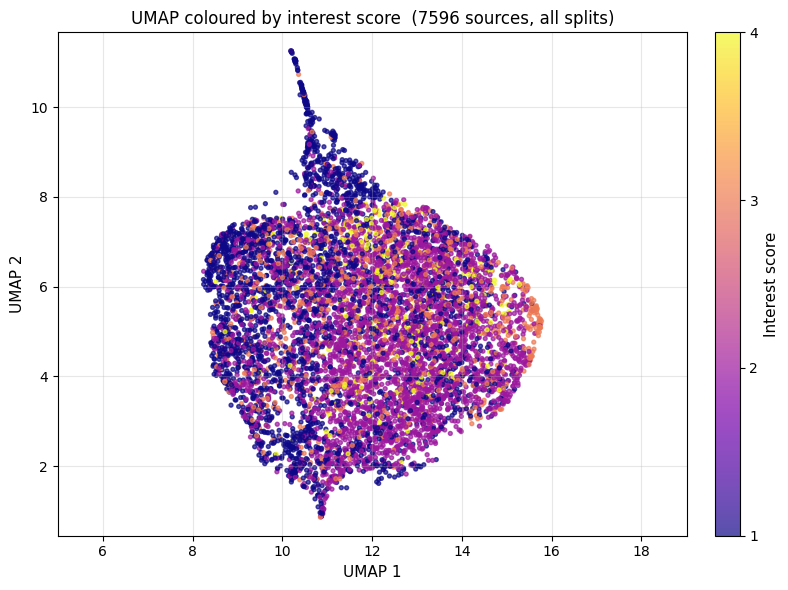

In [10]:
# UMAP is fitted on all sources (train + test) to match the training-script output.
_umap_new = Path(RUN_DIR) / "umap" / "umap_projections_coords.npy"
_umap_old = Path(RUN_DIR) / "umap_all_coords.npy"
_umap_cache = _umap_new if _umap_new.exists() else _umap_old
_all_human_labels = labels_df.loc[all_names, "human_label"].values
if _umap_cache.exists() and np.load(_umap_cache).shape[0] == all_proj.shape[0]:
    _emb2d = np.load(_umap_cache)
    print(f"Loaded UMAP from cache ({len(_emb2d)} sources)")
else:
    print(f"Fitting UMAP on {all_proj.shape[0]} sources...")
    _reducer = umap_lib.UMAP(n_neighbors=30, min_dist=0.1, metric='euclidean', random_state=42)
    _emb2d = _reducer.fit_transform(all_proj)
    _umap_new.parent.mkdir(parents=True, exist_ok=True)
    np.save(_umap_new, _emb2d)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    _emb2d[:, 0], _emb2d[:, 1],
    c=_all_human_labels, cmap='plasma',
    s=8, alpha=0.7, vmin=1, vmax=4,
)
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Interest score', fontsize=11)
cbar.set_ticks([1, 2, 3, 4])
ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
ax.set_aspect('equal', adjustable='datalim')
ax.grid(True, alpha=0.3)
ax.set_title(f'UMAP coloured by interest score  ({len(_emb2d)} sources, all splits)',
             fontsize=12)
plt.tight_layout()

# Save before plt.show(), which otherwise clears the figure from memory.
_fig_out = OUTPUTS_ROOT / "figures" / "protege" / "umap_interest_score.png"
_fig_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(_fig_out, dpi=300, bbox_inches='tight')
print(f"Saved figure to {_fig_out}")

plt.show()

### KNN Nearest-Neighbour Gallery

For each SCORE_4 class, picks one random member as a query and shows its 8 nearest neighbours in embedding space. A yellow border on the centre image marks the query; neighbours are ranked by cosine distance.

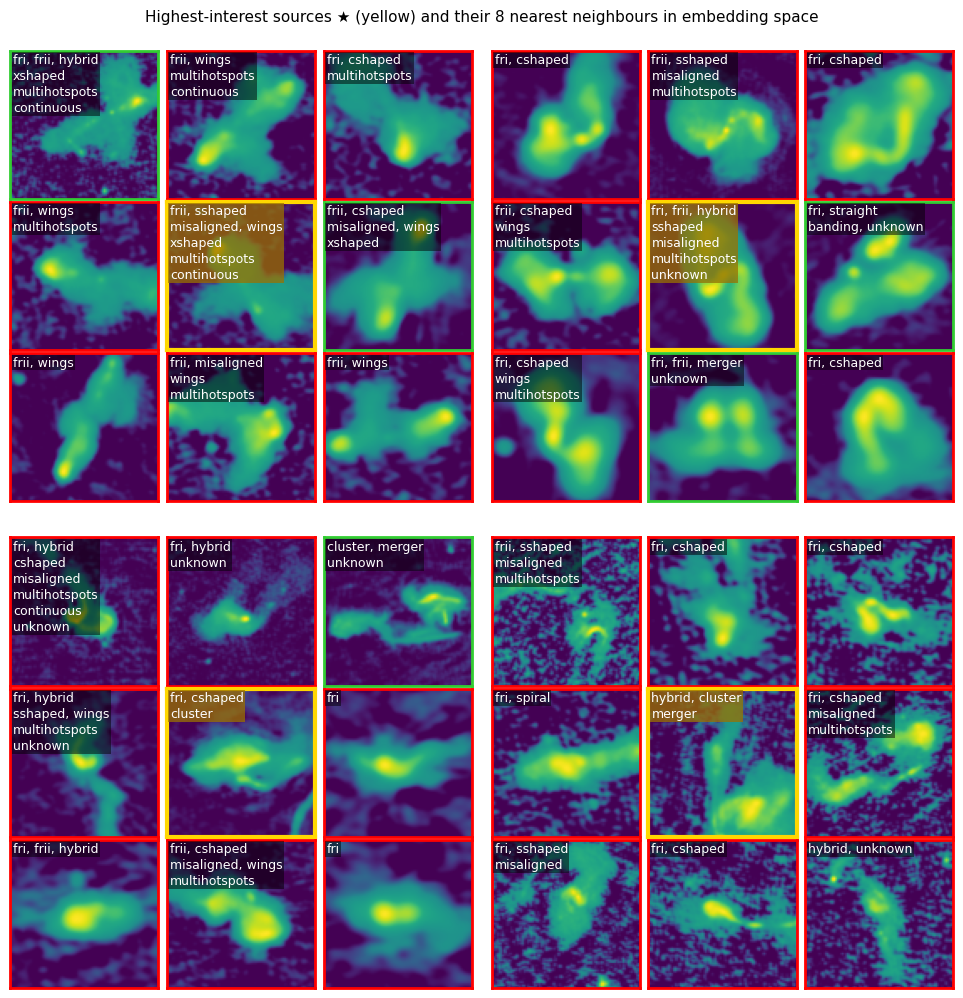

In [11]:
from matplotlib.gridspec import GridSpec

# =============================================================================
# KNN Gallery — highest-interest sources (SCORE_4 classes)
# Centre cell (yellow border) = query image (one random example per class).
# Surrounding 8 cells = nearest neighbours in embedding space.
# Green border = neighbour shares the query class; red = does not.
# =============================================================================
KNN_SEED  = 42
SEP       = 6 / 89
cell_size = 1.6

def _wrap_label(names, max_chars=18):
    lines, cur = [], ''
    for p in names:
        cand = f'{cur}, {p}' if cur else p
        if len(cand) > max_chars and cur:
            lines.append(cur); cur = p
        else:
            cur = cand
    if cur: lines.append(cur)
    return '\n'.join(lines)

rng_knn  = np.random.default_rng(KNN_SEED)
nn_model = NearestNeighbors(n_neighbors=9, metric='euclidean').fit(projections)

# One random query per SCORE_4 class
queries = []
for cls in SCORE_4:
    candidates = np.where(labels_npy_df[cls].values)[0]
    if len(candidates) == 0:
        continue
    idx = rng_knn.choice(candidates)
    queries.append((cls, idx))

N_CLASSES = len(queries)
N_TOP     = (N_CLASSES + 1) // 2   # galleries in top row
N_BOT     = N_CLASSES - N_TOP       # galleries in bottom row

# Width ratios: each gallery = 3 image columns, separated by 1 narrow SEP column
top_ratios = []
for _i in range(N_TOP):
    top_ratios += [1, 1, 1]
    if _i < N_TOP - 1:
        top_ratios.append(SEP)

_top_total = N_TOP * 3 + (N_TOP - 1) * SEP
_bot_used  = N_BOT * 3 + (N_BOT - 1) * SEP

if N_BOT == N_TOP:
    # Symmetric layout — no pad columns needed
    bot_ratios    = list(top_ratios)
    bot_col_start = 0
else:
    _pad = (_top_total - _bot_used) / 2
    bot_ratios = [_pad]
    for _i in range(N_BOT):
        bot_ratios += [1, 1, 1]
        if _i < N_BOT - 1:
            bot_ratios.append(SEP)
    bot_ratios.append(_pad)
    bot_col_start = 1

fig_width  = _top_total * cell_size
fig_height = (3 * cell_size + 0.2) * 2 + 0.3
fig = plt.figure(figsize=(fig_width, fig_height))
fig.patch.set_facecolor('white')

gs_outer = GridSpec(2, 1, figure=fig, hspace=0.08)
fig.subplots_adjust(top=0.93, bottom=0.02, left=0.01, right=0.99)
gs_top = gs_outer[0].subgridspec(3, len(top_ratios), wspace=0.005, hspace=0.02,
                                  width_ratios=top_ratios)
gs_bot = gs_outer[1].subgridspec(3, len(bot_ratios), wspace=0.005, hspace=0.02,
                                  width_ratios=bot_ratios)

sel_idxs       = np.array([idx for _, idx in queries])
_, knn_indices = nn_model.kneighbors(projections[sel_idxs])

def _fill_gallery(gs_row, col_offset, q_idx, nn_idxs, query_cls):
    neighbours = [i for i in nn_idxs if i != q_idx][:8]
    grid = [neighbours[0], neighbours[1], neighbours[2],
            neighbours[3], None,          neighbours[4],
            neighbours[5], neighbours[6], neighbours[7]]
    q_img = images[q_idx]
    if q_img.ndim == 3:
        q_img = q_img[0]
    for flat_pos, real_idx in enumerate(grid):
        r  = flat_pos // 3
        c  = col_offset + (flat_pos % 3)
        ax = fig.add_subplot(gs_row[r, c])
        if real_idx is None:
            # Query image — gold border
            ax.imshow(q_img, cmap='viridis', origin='lower')
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('gold')
                spine.set_linewidth(3)
            ax.axis('on'); ax.set_xticks([]); ax.set_yticks([])
            q_active = [col for col in LABEL_COLS if labels_npy_df.iloc[q_idx][col]]
            ax.text(0.02, 0.98, _wrap_label(q_active),
                    transform=ax.transAxes, fontsize=9, color='white',
                    va='top', ha='left', linespacing=1.3,
                    bbox=dict(facecolor='#9a7200', alpha=0.75, pad=1, linewidth=0))
        else:
            nb_img = images[real_idx]
            if nb_img.ndim == 3:
                nb_img = nb_img[0]
            ax.imshow(nb_img, cmap='viridis', origin='lower')
            nb_active = [col for col in LABEL_COLS if labels_npy_df.iloc[real_idx][col]]
            border_color = 'limegreen' if query_cls in nb_active else 'red'
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor(border_color)
                spine.set_linewidth(2)
            ax.set_xticks([]); ax.set_yticks([])
            ax.text(0.02, 0.98, _wrap_label(nb_active) if nb_active else '—',
                    transform=ax.transAxes, fontsize=9, color='white',
                    va='top', ha='left', linespacing=1.3,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1, linewidth=0))

for _gal_i, ((cls, q_idx), knn_row) in enumerate(zip(queries[:N_TOP], knn_indices[:N_TOP])):
    _fill_gallery(gs_top, _gal_i * 4, q_idx, knn_row, cls)

for _gal_i, ((cls, q_idx), knn_row) in enumerate(zip(queries[N_TOP:], knn_indices[N_TOP:])):
    _fill_gallery(gs_bot, bot_col_start + _gal_i * 4, q_idx, knn_row, cls)

fig.suptitle('Highest-interest sources ★ (yellow) and their 8 nearest neighbours in embedding space',
             fontsize=11, y=0.97, color='black')

_fig_dir = OUTPUTS_ROOT / "figures" / "protege"
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / "knn_gallery.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()


### Gaussian Process Active Learning Loop

Defines `run_GP_active_learning`, which wraps the Protege GP pipeline: it seeds `initial_steps` sources, then iteratively selects the highest-acquisition unlabelled sources, reveals ground-truth labels, and re-fits the GP until `N_labels` sources have been labelled.

The cell also standardises the full projection matrix with `StandardScaler` so the GP kernel operates on unit-variance features.

In [12]:
def run_GP_active_learning(features, labels, input_anomaly_scores, output_dir,
                           steps=10, initial_steps=None, N_labels=100, epsilon=0.5,
                           labelable_index=None):
    anomaly_scores = input_anomaly_scores.copy()
    anomaly_scores['human_label'] = [-1] * len(anomaly_scores)
    pipeline_active_learning = protege.GaussianProcess(
        features, force_rerun=True, output_dir=output_dir, ei_tradeoff=epsilon)

    def _pick_unlabeled(df, n):
        mask = df['human_label'] == -1
        if labelable_index is not None:
            mask = mask & df.index.isin(labelable_index)
        return df[mask].index[:n]

    if initial_steps is not None:
        anomaly_scores.sort_values('score', ascending=False, inplace=True)
        inds = _pick_unlabeled(anomaly_scores, initial_steps)
        anomaly_scores.loc[inds, 'human_label'] = labels.loc[inds, 'human_label']
        features_with_labels = pipeline_active_learning.combine_data_frames(features, anomaly_scores)
        active_output = pipeline_active_learning.run(features_with_labels)
        anomaly_scores['trained_score'] = active_output['trained_score']
        anomaly_scores['acquisition']   = active_output['acquisition']
    else:
        initial_steps = 0
    for i in range(initial_steps // steps, N_labels // steps):
        anomaly_scores.sort_values('acquisition', ascending=False, inplace=True)
        inds = _pick_unlabeled(anomaly_scores, steps)
        anomaly_scores.loc[inds, 'human_label'] = labels.loc[inds, 'human_label']
        features_with_labels = pipeline_active_learning.combine_data_frames(features, anomaly_scores)
        active_output = pipeline_active_learning.run(features_with_labels)
        anomaly_scores['trained_score'] = active_output['trained_score']
        anomaly_scores['acquisition']   = active_output['acquisition']
    return anomaly_scores, pipeline_active_learning


### PCA Dimensionality Reduction

Fits a PCA on the combined train+test projections (no prior scaling) and reports how many components explain 95% and 99% of variance. The embeddings are then projected to the 95%-variance component count to produce `features_pca`, which is passed to the GP active learner.

Embedding dim: 1280d  (analysis PCA on first 128 components)
  Dims for 95% variance: 97
  Dims for 99% variance: >128
  Variance captured by 128 components: 0.962


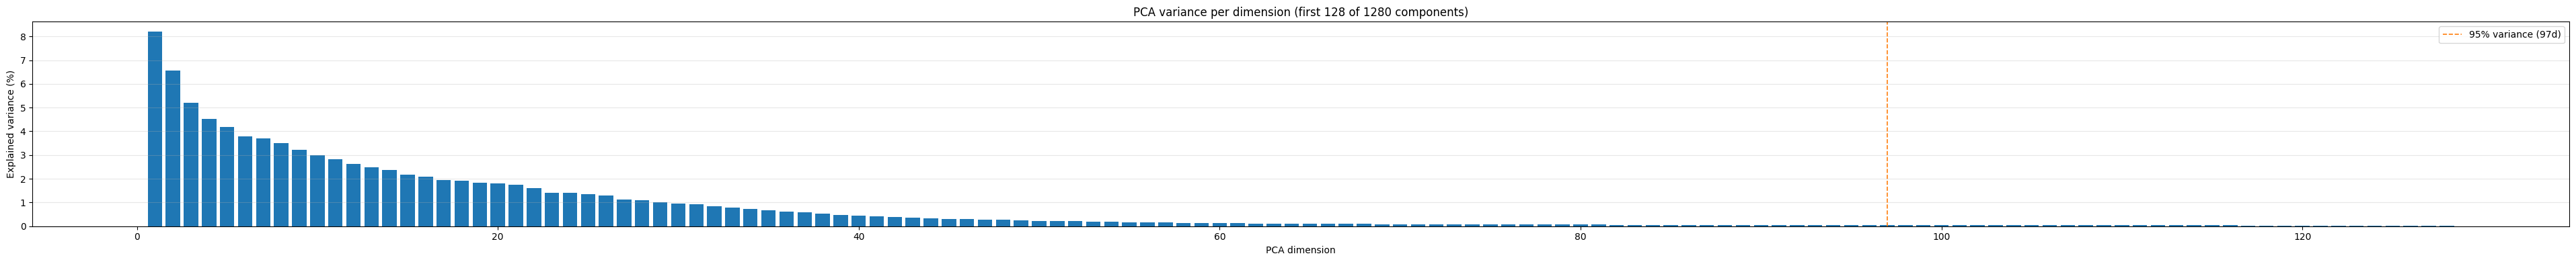


PCA applied: 1280d → 96d (0.950 variance retained)
features_pca: (7596, 96)  (train=5317, test=2279)


In [13]:
# No scaling — PCA will be applied directly to the raw projections if enabled.
all_proj_scaled    = all_proj
projections_scaled = all_proj[:n_train]
test_proj_scaled   = all_proj[n_train:]

# Always fit a partial PCA for variance analysis (fast: only 128 components)
_n_analysis = min(128, all_proj.shape[1])
_pca_analysis = PCA(n_components=_n_analysis, random_state=42)
_pca_analysis.fit(all_proj_scaled)

_cumvar = np.cumsum(_pca_analysis.explained_variance_ratio_)
_n_95   = int(np.searchsorted(_cumvar, 0.95)) + 1 if _cumvar[-1] >= 0.95 else f">{_n_analysis}"
_n_99   = int(np.searchsorted(_cumvar, 0.99)) + 1 if _cumvar[-1] >= 0.99 else f">{_n_analysis}"
print(f"Embedding dim: {all_proj.shape[1]}d  (analysis PCA on first {_n_analysis} components)")
print(f"  Dims for 95% variance: {_n_95}")
print(f"  Dims for 99% variance: {_n_99}")
print(f"  Variance captured by {_n_analysis} components: {_cumvar[-1]:.3f}")

fig, ax = plt.subplots(figsize=(max(6, _n_analysis * 0.3), 4))
ax.bar(np.arange(1, _n_analysis + 1), _pca_analysis.explained_variance_ratio_ * 100, color="tab:blue")
if isinstance(_n_95, int):
    ax.axvline(_n_95, color="tab:orange", linestyle="--", linewidth=1.2, label=f"95% variance ({_n_95}d)")
if isinstance(_n_99, int):
    ax.axvline(_n_99, color="tab:red",    linestyle=":",  linewidth=1.2, label=f"99% variance ({_n_99}d)")
ax.set_xlabel("PCA dimension")
ax.set_ylabel("Explained variance (%)")
ax.set_title(f"PCA variance per dimension (first {_n_analysis} of {all_proj.shape[1]} components)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

_figures_dir = OUTPUTS_ROOT / "figures" / "protege"
_pca_fig_path = _figures_dir / "pca_variance.png"
if not _pca_fig_path.exists():
    _figures_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_pca_fig_path, dpi=150, bbox_inches="tight")
    print(f"  Saved missing pca_variance.png to {_pca_fig_path}")

plt.show()

if APPLY_PCA:
    pca = PCA(n_components=0.95, random_state=42)
    projections_pca  = pca.fit_transform(projections_scaled)
    test_proj_pca    = pca.transform(test_proj_scaled)
    all_proj_pca     = np.concatenate([projections_pca, test_proj_pca], axis=0)
    features_pca     = pd.DataFrame(all_proj_pca, index=all_names)
    print(f"\nPCA applied: {all_proj.shape[1]}d → {projections_pca.shape[1]}d "
          f"({pca.explained_variance_ratio_.sum():.3f} variance retained)")
else:
    features_pca = pd.DataFrame(all_proj_scaled, index=all_names)
    print(f"\nPCA not applied — using full {all_proj.shape[1]}d embeddings.")

print(f"features_pca: {features_pca.shape}  (train={n_train}, test={len(all_proj)-n_train})")
assert len(features_pca) == len(all_proj), "features_pca row count mismatch!"

### Run Gaussian Process Active Learning

Seeds the GP with `INITIAL_STEPS` evenly-spaced train sources using ground-truth interest scores, then calls `run_GP_active_learning` to run the full active-learning loop. Results are saved to `{RUN_DIR}/protege/` as a parquet file.

In [14]:
assert len(features_pca) > n_train, (
    f"features_pca has {len(features_pca)} rows but n_train={n_train}: "
    "no test rows — re-run the PCA cell before this one.")
features_train = features_pca.iloc[:n_train]
features_test  = features_pca.iloc[n_train:]

_nb_protege_dir = Path(RUN_DIR) / "protege"
_nb_protege_dir.mkdir(parents=True, exist_ok=True)

# Canonical filenames:
#   _script_parquet — written by train_byol_proteges.py (preferred source)
#   _nb_parquet     — written by this cell when run from scratch
_script_parquet = _nb_protege_dir / f"protege_scores_{_latent_tag}.parquet"
_nb_parquet     = _nb_protege_dir / f"protege_scores_nb_{_latent_tag}_eps{EPSILON:g}.parquet"

def _load_gp_parquet(path):
    """Load a GP-scores parquet saved by either the script or this cell."""
    _df = pd.read_parquet(path)
    _active = _df.loc[features_train.index].copy()
    _test   = _df.loc[features_test.index, ['trained_score', 'acquisition']].copy()
    _test['human_label'] = -2   # sentinel for downstream cells
    return _active, _test

if _script_parquet.exists():
    print(f"Loading pre-computed GP scores from script: {_script_parquet.name}")
    active_output, test_output = _load_gp_parquet(_script_parquet)
    print(f"  {len(active_output)} train  |  {len(test_output)} test sources")

elif _nb_parquet.exists():
    print(f"Loading saved notebook GP scores: {_nb_parquet.name}")
    active_output, test_output = _load_gp_parquet(_nb_parquet)
    print(f"  {len(active_output)} train  |  {len(test_output)} test sources")

else:
    print("No pre-computed GP scores found — running GP active learning from scratch…")
    print(f"(Will label all {n_train} train sources in batches of {STEPS_PER_ITER}.)")

    # Seed with human_label values (1–4) for INITIAL_STEPS evenly-spaced sources
    anomaly_scores = pd.DataFrame({'score': np.zeros(len(features_pca))}, index=features_pca.index)
    seed_positions = np.linspace(0, n_train - 1, INITIAL_STEPS, dtype=int)
    seed_names = features_train.index[seed_positions]
    anomaly_scores.loc[seed_names, 'score'] = labels_df.loc[seed_names, 'human_label'].values.astype(float)
    n_positive_seeds = (labels_df.loc[seed_names, 'human_label'] >= POSITIVE_THRESHOLD).sum()
    print(f"Seed set: {INITIAL_STEPS} sources, {n_positive_seeds} with score >= {POSITIVE_THRESHOLD} "
          f"({100 * n_positive_seeds / INITIAL_STEPS:.1f}%)")

    score_converter = human_loop_learning.ScoreConverter(force_rerun=True, output_dir=str(_nb_protege_dir))
    anomaly_scores = score_converter.run(anomaly_scores)

    active_output, gp_pipeline = run_GP_active_learning(
        features_pca,
        labels_df.loc[features_train.index],
        anomaly_scores,
        output_dir=str(_nb_protege_dir),
        steps=STEPS_PER_ITER,
        initial_steps=INITIAL_STEPS,
        N_labels=n_train,            # label all train sources — matches script behaviour
        epsilon=EPSILON,
        labelable_index=features_train.index,
    )

    test_output = active_output.loc[features_test.index, ['trained_score', 'acquisition']].copy()
    test_output['human_label'] = -2

    # Save so this cell can be skipped on future runs
    _combined = pd.concat([
        active_output.loc[features_train.index, ['trained_score', 'acquisition', 'human_label']],
        test_output[['trained_score', 'acquisition', 'human_label']],
    ])
    _combined.to_parquet(_nb_parquet)
    print(f"Saved → {_nb_parquet}")

print(f"Train labelled: {(active_output.loc[features_train.index, 'human_label'] > 0).sum()}")
print(f"Test scored:    {len(test_output)}  |  positives (score≥3): "
      f"{(labels_df.loc[features_test.index, 'human_label'] >= 3).sum()}")


Loading pre-computed GP scores from script: protege_scores_enc_pca.parquet
  5317 train  |  2279 test sources
Train labelled: 5317
Test scored:    2279  |  positives (score≥3): 383


### Recall Curve

Ranks queried-train and test sources by the GP's `trained_score` and plots cumulative interesting-source counts (label ≥ `POSITIVE_THRESHOLD`) on two side-by-side subplots (train left, test right). Baselines overlaid for comparison:
- **Orange** — BYOL GP (this run)
- **Steelblue dashed** — Complexity (featurecount ranking)
- **Green dotted** — Ellipses GP (IsoForest + Protege GP on shape features)
- **Dark grey dashed** — Random baseline

The figure is saved to `{RUN_DIR}/../figures/recall_curves_{latent}_eps{EPSILON}.png`. The cell also scans `{RUN_DIR}/protege/` for previously saved runs at other `EPSILON` values and overlays them on the test subplot for direct epsilon comparison.

In [15]:
# ── Compute / load baselines (complexity + ellipses) on the test set ─────────
# Ellipses IsoForest is fitted on ALL images (unsupervised, no split needed).
# Results are keyed by data_seed and hash-validated against test_idx.npy.

# data_seed: prefer protege_summary.json if available, else fall back to 42
_summary_path = Path(RUN_DIR).parent / "protege" / "protege_summary.json"
if not _summary_path.exists():
    _summary_path = Path(RUN_DIR) / "protege" / "protege_summary.json"
if _summary_path.exists():
    with open(_summary_path) as _fh:
        _data_seed = int(json.load(_fh).get("data_seed", 42))
else:
    _data_seed = 42

# test_idx.npy: check shared splits_dir first, then data_dir (old runs)
_splits_dir_bl    = OUTPUTS_ROOT / "data_splits" / str(_data_seed)
_test_idx_in_splits = _splits_dir_bl / "test_idx.npy"
_test_idx_path    = _test_idx_in_splits if _test_idx_in_splits.exists() else Path(RUN_DIR) / "test_idx.npy"
_hash             = hashlib.sha256(open(_test_idx_path, "rb").read()).hexdigest()
(OUTPUTS_ROOT / "anomaly_baselines").mkdir(parents=True, exist_ok=True)
_baselines_path   = OUTPUTS_ROOT / "anomaly_baselines" / f"baselines_{_data_seed}.json"

# ── One-time cache invalidation ────────────────────────────────────────────────
# upper_limit was raised from the library default (100) to 150 (see _ext below),
# which changes which sources succeed in EllipseFitFeatures.  Any on-disk caches
# built with the old features are stale and must be deleted.
# TODO: once new features are on disk, remove the shutil.rmtree / unlink calls
#       below AND set force_rerun=False on _ext.
import shutil as _shutil
for _stale_dir in [
    OUTPUTS_ROOT / "anomaly_baselines" / f"_ell_cache_{_data_seed}",
    OUTPUTS_ROOT / "anomaly_baselines" / f"_ell_gp_cache_{_data_seed}",
]:
    if _stale_dir.exists():
        _shutil.rmtree(_stale_dir)
        print(f"Deleted stale cache dir: {_stale_dir.name}")
if _baselines_path.exists():
    _baselines_path.unlink()
    print(f"Deleted stale baselines: {_baselines_path.name}")

# ── Always build _all_ell + _iforest ──────────────────────────────────────────
_images_all = np.load(IMAGES_PATH).astype(np.float32) / 255.0
_ell_outdir = OUTPUTS_ROOT / "anomaly_baselines" / f"_ell_cache_{_data_seed}"
_ell_outdir.mkdir(exist_ok=True)

class _NumpyImageDataset(_AstroDataset):
    def __init__(self, images, output_dir, **kwargs):
        super().__init__(output_dir=output_dir, **kwargs)
        self.images   = images
        self.index    = [str(i) for i in range(len(images))]
        self.metadata = pd.DataFrame(index=self.index)
    def get_sample(self, idx):       return self.images[int(idx)]
    def get_display_data(self, idx): return {}

_ds  = _NumpyImageDataset(_images_all, output_dir=str(_ell_outdir), force_rerun=False)
# upper_limit=150: the library default is 100, which disables the built-in
# upscaling retry inside EllipseFitFeatures.  Raising it to 150 allows sources
# whose innermost ellipse contour has <5 points to be refitted at a higher image
# resolution, rescuing many of the ~18.5% of sources that previously produced
# all-NaN feature vectors.
# force_rerun=True: required for this one-time recompute after cache deletion.
# Set force_rerun=False here (and remove the cache-clearing block above) once
# the new feature cache is on disk.
_ext = _sf.EllipseFitFeatures(percentiles=[90, 80, 70, 60, 50, 0], channel=0,
                               output_dir=str(_ell_outdir), force_rerun=True,
                               upper_limit=150)
_all_ell = _ext.run_on_dataset(_ds)

# ── Diagnostics: NaN count before vs after upper_limit change ─────────────────
_ell_nan_mask = _all_ell.isna().any(axis=1)
_n_ell_nan    = int(_ell_nan_mask.sum())
_n_ell_total  = len(_all_ell)
_n_prev_nan   = round(0.185 * _n_ell_total)   # ~18.5% known rate with upper_limit=100
_n_rescued    = max(0, _n_prev_nan - _n_ell_nan)
print(f"EllipseFit NaN rows — before (upper_limit=100): ~{_n_prev_nan}/{_n_ell_total}"
      f" ({100 * _n_prev_nan / _n_ell_total:.1f}%)")
print(f"EllipseFit NaN rows — after  (upper_limit=150):  {_n_ell_nan}/{_n_ell_total}"
      f" ({100 * _n_ell_nan / _n_ell_total:.1f}%)")
print(f"Sources rescued by higher upper_limit: ~{_n_rescued}"
      f"  ({100 * _n_rescued / _n_ell_total:.1f}% of dataset)")

# ── IsoForest fit: median imputation instead of dropping NaN rows ─────────────
# Previously: _all_ell_clean = _all_ell[~_ell_nan_mask]  (dropped ~18.5% of sources)
# Now: fill remaining all-NaN rows with per-column medians computed from valid rows
# only, so every source contributes to the IsoForest density model and receives a
# score.  Imputed values are neutral (median of the observed distribution) so they
# do not bias the anomaly score in either direction.
_ell_col_medians = _all_ell[~_ell_nan_mask].median()   # one value per feature column
_all_ell_imp     = _all_ell.copy()
_all_ell_imp[_ell_nan_mask] = _all_ell_imp[_ell_nan_mask].fillna(_ell_col_medians)
_n_imp_iso = int(_ell_nan_mask.sum())
print(f"IsoForest imputation: {_n_imp_iso} NaN rows filled with column medians "
      f"(all {_n_ell_total} sources scored)")

_iforest = _IsoForest(n_estimators=200, random_state=_data_seed)
_iforest.fit(_all_ell_imp.values)

baselines = None
if _baselines_path.exists():
    with open(_baselines_path) as _fh:
        _cached = json.load(_fh)
    if _cached.get("test_idx_hash") == _hash:
        baselines = _cached
        print(f"Loaded baselines from cache  (seed={_data_seed}, n_eval={baselines['n_eval']})")
        # Invalidate cached ellipses_gp if it was computed on a smaller test set
        # (old runs dropped NaN-feature sources from the test set)
        _eg = baselines.get("ellipses_gp")
        if _eg and _eg.get("x") and len(_eg["x"]) != baselines["n_eval"]:
            print(f"  Invalidating cached ellipses_gp (n={len(_eg['x'])} ≠ n_eval={baselines['n_eval']})")
            baselines["ellipses_gp"] = None

if baselines is None:
    print(f"Computing baselines (seed={_data_seed}) ...")
    # Reuse _test_idx and _test_human defined in cell 15
    _n_eval = len(_test_idx)
    _x      = np.arange(1, _n_eval + 1)
    _n_pos  = int((_test_human >= POSITIVE_THRESHOLD).sum())

    # ── Complexity: rank by featurecount descending ───────────────────────────
    _fc         = pd.read_csv(CSV_PATH)["featurecount"].values[_test_idx]
    _comp_order = np.argsort(_fc)[::-1]
    _cum_comp   = np.cumsum((_test_human[_comp_order] >= POSITIVE_THRESHOLD).astype(int))
    _auc_comp   = float(np.trapz(_cum_comp, _x) / (_n_eval * _n_pos)) if _n_pos > 0 else 0.0
    print(f"  complexity AUC={_auc_comp:.4f}")

    baselines = {
        "test_idx_hash": _hash, "data_seed": _data_seed,
        "n_eval": _n_eval, "n_pos": _n_pos,
        "complexity": {"recall": _cum_comp.tolist(), "x": _x.tolist(), "auc": _auc_comp},
    }
    with open(_baselines_path, "w") as _fh:
        json.dump(baselines, _fh)
    print(f"Saved to {_baselines_path}")

# ── Correlation: featurecount vs positive label (test set) ───────────────────
_fc_all     = pd.read_csv(CSV_PATH)["featurecount"].values[_test_idx]
_pos_binary = (_test_human >= POSITIVE_THRESHOLD).astype(float)
_corr       = float(np.corrcoef(_fc_all.astype(float), _pos_binary)[0, 1])
print(f"featurecount/label correlation — test set ({len(_test_idx)} sources): r={_corr:.4f}")

# ── Ellipses GP — IsoForest + Protege GP (computed inline) ───────────────────
_ell_gp = baselines.get("ellipses_gp") if baselines else None

if _ell_gp is None:
    print("Computing Ellipses GP baseline ...")
    try:
        # Align already-imputed ellipse features to train/test source names.
        # _all_ell_imp has no NaNs; the per-train-median pass below is a safety
        # net for any residual NaNs that might survive (e.g. all-NaN columns).
        _tr_ell = _all_ell_imp.iloc[idx_arr].copy();   _tr_ell.index = source_names
        _te_ell = _all_ell_imp.iloc[_test_idx].copy(); _te_ell.index = _test_names

        # ── GP block: median imputation on train/test subsets ─────────────────
        # Medians are computed on TRAIN valid rows only so test values never
        # influence the imputed features of other test sources (no test leakage).
        # No source is dropped or ranked last.
        _tr_ell_nan = _tr_ell.isna().any(axis=1)
        _te_ell_nan = _te_ell.isna().any(axis=1)
        _n_tr_imp_gp = int(_tr_ell_nan.sum())
        _n_te_imp_gp = int(_te_ell_nan.sum())
        if _n_tr_imp_gp > 0 or _n_te_imp_gp > 0:
            _tr_med_gp = _tr_ell[~_tr_ell_nan].median()   # train valid rows only
            _tr_ell    = _tr_ell.fillna(_tr_med_gp)
            _te_ell    = _te_ell.fillna(_tr_med_gp)        # train medians → no test leakage
        print(f"  GP block imputation: {_n_tr_imp_gp} train + {_n_te_imp_gp} test NaN rows "
              f"filled  ({len(_tr_ell)} train, {len(_te_ell)} test sources, none dropped)")

        # IsoForest scores → normalize to [0.1, 5]
        _tr_iso  = _iforest.decision_function(_tr_ell.values)
        _te_iso  = _iforest.decision_function(_te_ell.values)
        _iso_all = -np.concatenate([_tr_iso, _te_iso])
        _iso_rng = _iso_all.max() - _iso_all.min()
        _iso_norm    = 0.1 + (5 - 0.1) * (_iso_all - _iso_all.min()) / (_iso_rng + 1e-9)
        _tr_iso_norm = _iso_norm[:len(_tr_iso)]
        _te_iso_norm = _iso_norm[len(_tr_iso):]

        # Full-budget train labels (covers all train sources)
        _tr_human_gp = labels_df.loc[_tr_ell.index, "human_label"].values.astype(float)

        # Scale features for GP
        _scaler_ell  = StandardScaler()
        _tr_scaled   = _scaler_ell.fit_transform(_tr_ell.values)
        _te_scaled   = _scaler_ell.transform(_te_ell.values)
        _cols        = [f"f{i}" for i in range(_tr_scaled.shape[1])]
        _tr_feat     = pd.DataFrame(_tr_scaled, index=_tr_ell.index, columns=_cols)
        _te_feat     = pd.DataFrame(_te_scaled, index=_te_ell.index, columns=_cols)
        _all_feat_gp = pd.concat([_tr_feat, _te_feat])

        _scores_gp = pd.DataFrame({
            "score":       np.concatenate([_tr_iso_norm, _te_iso_norm]),
            "human_label": np.concatenate([_tr_human_gp, np.full(len(_te_ell), -1.0)]),
        }, index=_all_feat_gp.index)

        print(f"  Running GP on {len(_tr_ell)} train + {len(_te_ell)} test sources ...")
        _ell_gp_outdir = OUTPUTS_ROOT / "anomaly_baselines" / f"_ell_gp_cache_{_data_seed}"
        _ell_gp_outdir.mkdir(exist_ok=True)
        _ell_gp_pipeline = protege.GaussianProcess(
            _all_feat_gp, force_rerun=True,
            output_dir=str(_ell_gp_outdir),
            ei_tradeoff=EPSILON,
        )
        _fwl    = _ell_gp_pipeline.combine_data_frames(_all_feat_gp, _scores_gp)
        _gp_out = _ell_gp_pipeline.run(_fwl)

        # All test sources now have a GP score; no "ranked last" fallback needed
        _te_scored = _gp_out.loc[_te_ell.index, "trained_score"].sort_values(ascending=False)
        _te_tl     = pd.Series(_test_human, index=_test_names).loc[_te_scored.index]
        _n_pos_all = int((_test_human >= POSITIVE_THRESHOLD).sum())
        _cum_gp    = np.cumsum((_te_tl >= POSITIVE_THRESHOLD).astype(int).values)
        _x_gp      = np.arange(1, len(_cum_gp) + 1)
        _auc_gp    = float(np.trapz(_cum_gp, _x_gp) / (len(_cum_gp) * _n_pos_all))                      if _n_pos_all > 0 else 0.0
        _ell_gp = {"recall": _cum_gp.tolist(), "x": _x_gp.tolist(), "auc": _auc_gp}
        print(f"  Ellipses GP AUC={_auc_gp:.4f}  (n_eval={len(_cum_gp)}, n_pos={_n_pos_all})")
    except Exception as _e:
        print(f"  Ellipses GP failed: {_e}")
        import traceback; traceback.print_exc()

baselines["ellipses_gp"] = _ell_gp
with open(_baselines_path, "w") as _fh:
    json.dump(baselines, _fh)
if _ell_gp is not None:
    print(f"Baselines (incl. Ellipses GP AUC={_ell_gp['auc']:.4f}) saved to {_baselines_path}")
else:
    print(f"Baselines saved to {_baselines_path}  (Ellipses GP: not available)")

Deleted stale cache dir: _ell_cache_42
Deleted stale cache dir: _ell_gp_cache_42
Deleted stale baselines: baselines_42.json
Extracting features using EllipseFitFeatures ...
0 instances completed
100 instances completed
200 instances completed
300 instances completed
400 instances completed
500 instances completed
600 instances completed
700 instances completed
800 instances completed
900 instances completed
1000 instances completed
1100 instances completed
1200 instances completed
1300 instances completed
1400 instances completed
1500 instances completed
1600 instances completed
1700 instances completed
1800 instances completed
1900 instances completed
2000 instances completed
2100 instances completed
2200 instances completed
2300 instances completed
2400 instances completed
2500 instances completed
2600 instances completed
2700 instances completed
2800 instances completed
2900 instances completed
3000 instances completed
3100 instances completed
3200 instances completed
3300 instances

#### Complexity Baseline (Multi-Seed)

Ranks all sources by their radio-component feature count (`featurecount`) as a complexity proxy, across 10 random train/test splits. Cumulative recall curves are computed per seed and overlaid on the recall plot as a simple unsupervised baseline.

In [16]:
# ── Multi-seed complexity baseline (no training needed) ──────────────────────
COMPLEXITY_SEEDS = [42, 1, 2, 3, 4, 5, 6, 7, 8, 9]
_BOLD_SEED       = 42

_labels_ms  = np.load(LABELS_NPY_PATH)          # (7596, 20)
_fc_all     = pd.read_csv(CSV_PATH)["featurecount"].values  # (7596,)
_n_total    = len(_labels_ms)

def _build_hl(idx):
    """Build integer human_label array for given global indices."""
    _ldf = pd.DataFrame(_labels_ms[idx].astype(bool), columns=LABEL_COLS)
    _hl  = np.ones(len(_ldf), dtype=int)
    for _sv, _cols in reversed(TIERS):
        _hl[_ldf[_cols].any(axis=1).values] = _sv
    return _hl

def _comp_recall(hl, fc):
    """Complexity recall curve: rank fc descending, cumsum positives."""
    order = np.argsort(fc)[::-1]
    cum   = np.cumsum((hl[order] >= POSITIVE_THRESHOLD).astype(int))
    x     = np.arange(1, len(cum) + 1)
    n_pos = int((hl >= POSITIVE_THRESHOLD).sum())
    auc   = float(np.trapz(cum, x) / (len(cum) * n_pos)) if n_pos > 0 else 0.0
    return x, cum, n_pos, auc

# ── Test curves: vary the train/test split seed ───────────────────────────────
_ref_n_test = len(_test_idx)

_comp_test_curves = {}   # seed → cum array (length _ref_n_test)
_comp_test_aucs   = {}   # seed → AUC

for _s in COMPLEXITY_SEEDS:
    _tr_idx_s, _te_idx_s = train_test_split(np.arange(_n_total), test_size=0.30, random_state=_s)
    _hl_te  = _build_hl(_te_idx_s)
    _fc_te  = _fc_all[_te_idx_s]
    _x_te, _cum_te, _n_pos_te, _auc_te = _comp_recall(_hl_te, _fc_te)
    # Interpolate to reference length; keep absolute counts
    _x_norm = _x_te / len(_x_te)
    _x_ref  = np.arange(1, _ref_n_test + 1) / _ref_n_test
    _comp_test_curves[_s] = np.interp(_x_ref, _x_norm, _cum_te / max(_cum_te[-1], 1)) * _cum_te[-1]
    _comp_test_aucs[_s]   = _auc_te

# ── Train curves: fix seed-42 split, vary which n_queried sources are sampled ─
# This shows: "if instead of GP, you randomly picked n_queried sources from the
# train pool and ranked by complexity, what's the variability?"
# All curves are normalized to the seed-42 sample's positive count so they are
# directly comparable with the main BYOL line.
if 'active_output' in dir():
    _ref_n_train = int((active_output['human_label'] != -1).sum())
else:
    _ref_n_train = int(min(N_LABELS_TOTAL, n_train))
_tr_idx_42, _ = train_test_split(np.arange(_n_total), test_size=0.30, random_state=42)

_comp_train_curves  = {}   # seed → cum array (length _ref_n_train, scaled to ref n_pos)
_comp_train_aucs    = {}   # seed → AUC
_ref_n_pos_train    = None  # positive count from seed-42 sample (set first iteration)

for _s in COMPLEXITY_SEEDS:
    _rng_s  = np.random.default_rng(_s)
    _samp_s = _rng_s.choice(_tr_idx_42, size=min(_ref_n_train, len(_tr_idx_42)), replace=False)
    _hl_tr  = _build_hl(_samp_s)
    _fc_tr  = _fc_all[_samp_s]
    _x_tr, _cum_tr, _n_pos_tr, _auc_tr = _comp_recall(_hl_tr, _fc_tr)

    if _ref_n_pos_train is None:   # seed 42 always comes first
        _ref_n_pos_train = _n_pos_tr

    # Normalize fraction then scale to reference n_pos so all curves are comparable
    _cum_tr_frac = _cum_tr / max(_n_pos_tr, 1)
    _comp_train_curves[_s] = _cum_tr_frac * _ref_n_pos_train
    _comp_train_aucs[_s]   = _auc_tr

# Band arrays: (10, n) → 16th/84th percentile along axis=0
_comp_test_mat  = np.array([_comp_test_curves[s]  for s in COMPLEXITY_SEEDS])
_comp_train_mat = np.array([_comp_train_curves[s] for s in COMPLEXITY_SEEDS])
_p16_te, _p84_te = np.percentile(_comp_test_mat,  16, axis=0), np.percentile(_comp_test_mat,  84, axis=0)
_p16_tr, _p84_tr = np.percentile(_comp_train_mat, 16, axis=0), np.percentile(_comp_train_mat, 84, axis=0)

print(f"Computed complexity curves for {len(COMPLEXITY_SEEDS)} seeds.")
print(f"Train: {_ref_n_train} queried sources, reference n_pos={_ref_n_pos_train} (seed-42 random sample)")


Computed complexity curves for 10 seeds.
Train: 5317 queried sources, reference n_pos=920 (seed-42 random sample)


#### Ellipses IsoForest + Protege GP Baseline

Implements the astronomaly/Lochner & Bassett (2021) ellipse pipeline:
1. `EllipseFitFeatures` → 21 morphology features (already extracted as `_all_ell`)
2. `IsolationForest` → initial anomaly scores (already fitted as `_iforest`)
3. `ScoreConverter` → normalize scores to [0.1, 5] (inline)
4. `protege.GaussianProcess` run **once** (one-shot) with all available human labels

This provides an apples-to-apples comparison with the Protege GP run: same labelling budget, same source selection, but ellipse features + IsoForest initial scores instead of BYOL embeddings.

In [17]:
_ell_gp_nb_train = None   # kept for downstream plot cells
_ell_gp_nb_test  = None
_ell_gp_nb_cache = _nb_protege_dir / f"ellipses_gp_nb_q{n_train}.parquet"

# ── One-time nb-level cache invalidation ──────────────────────────────────────
# The parquet was built with old features (upper_limit=100) and possibly excluded
# NaN sources.  Delete it so we recompute with the new upper_limit=150 features
# and full median imputation.
# TODO: remove this block after the first successful recompute.
if _ell_gp_nb_cache.exists():
    _ell_gp_nb_cache.unlink()
    print(f"Deleted stale nb ellipses GP cache: {_ell_gp_nb_cache.name}")

def _load_ell_gp_nb_cache(path, train_index, test_index):
    if not path.exists():
        return None
    try:
        _df = pd.read_parquet(path)
        _tr = _df[_df["split"] == "train"]["trained_score"]
        _te = _df[_df["split"] == "test"]["trained_score"]
        if not set(train_index).issubset(set(_tr.index)):
            print("Ellipses GP (nb): cache train index mismatch — ignoring")
            return None
        return _tr, _te
    except Exception as _ex:
        print(f"Ellipses GP (nb): cache read error ({_ex}) — ignoring")
        return None

def _save_ell_gp_nb_cache(path, train_series, test_series):
    _tr_df = train_series.to_frame("trained_score"); _tr_df["split"] = "train"
    _te_df = test_series.to_frame("trained_score");  _te_df["split"] = "test"
    pd.concat([_tr_df, _te_df]).to_parquet(path)
    print(f"Ellipses GP (nb): saved → {path}")

try:
    # ── 1. Try cache ──────────────────────────────────────────────────────────
    _cached = _load_ell_gp_nb_cache(_ell_gp_nb_cache, features_train.index, features_test.index)
    if _cached is not None:
        _ell_gp_nb_train, _ell_gp_nb_test = _cached
        print(f"Ellipses GP (nb): loaded from cache  "
              f"(train={len(_ell_gp_nb_train)}, test={len(_ell_gp_nb_test)})")

    # ── 2. Compute from scratch ───────────────────────────────────────────────
    if _ell_gp_nb_train is None:
        # Ellipse features (raw, unscaled — matches _iforest fit).
        # idx_arr = global image indices for train (same order as features_train)
        # _test_idx = global image indices for test (same order as features_test)
        _tr_ell = _all_ell.iloc[idx_arr].copy()
        _tr_ell.index = features_train.index
        _te_ell = _all_ell.iloc[_test_idx].copy()
        _te_ell.index = features_test.index

        # ── Median imputation (replaces NaN-drop) ─────────────────────────────
        # Previously NaN rows were dropped and those sources were excluded from
        # the GP entirely.  Now we fill any remaining all-NaN rows with per-column
        # medians so that every source is included and no source is ranked last.
        # Medians are computed on TRAIN valid rows only so that test sources
        # never influence their own imputed values (no test leakage).
        _tr_nan, _te_nan   = _tr_ell.isna().any(axis=1), _te_ell.isna().any(axis=1)
        _n_tr_nan, _n_te_nan = int(_tr_nan.sum()), int(_te_nan.sum())
        if _n_tr_nan > 0 or _n_te_nan > 0:
            _tr_medians_nb = _tr_ell[~_tr_nan].median()      # train valid rows only
            _tr_ell        = _tr_ell.fillna(_tr_medians_nb)
            _te_ell        = _te_ell.fillna(_tr_medians_nb)  # train medians → no test leakage
        print(f"Ellipses GP (nb): imputed {_n_tr_nan} train + {_n_te_nan} test NaN rows "
              f"(no sources dropped; {len(_tr_ell)} train + {len(_te_ell)} test total)")
        # Aliases for readability; now cover the full source sets (no NaN rows dropped)
        _tr_ell_ok, _te_ell_ok = _tr_ell, _te_ell

        # IsoForest scores → normalize to [0.1, 5] (ScoreConverter: negate + min-max)
        _tr_iso  = _iforest.decision_function(_tr_ell_ok.values)
        _te_iso  = _iforest.decision_function(_te_ell_ok.values)
        _iso_all = -np.concatenate([_tr_iso, _te_iso])
        _iso_norm = 0.1 + (5 - 0.1) * (_iso_all - _iso_all.min()) / (_iso_all.max() - _iso_all.min())
        _tr_iso_norm = _iso_norm[:len(_tr_iso)]
        _te_iso_norm = _iso_norm[len(_tr_iso):]

        # All train sources are labeled (full budget — matches script behaviour)
        _tr_human = labels_df.loc[_tr_ell_ok.index, "human_label"].values.astype(float)

        # Scale features for GP
        _scaler_ell_gp = StandardScaler()
        _tr_scaled = _scaler_ell_gp.fit_transform(_tr_ell_ok.values)
        _te_scaled = _scaler_ell_gp.transform(_te_ell_ok.values)

        # Feature DataFrames (all sources = train + test)
        _cols = [f"f{i}" for i in range(_tr_scaled.shape[1])]
        _tr_feat = pd.DataFrame(_tr_scaled, index=_tr_ell_ok.index, columns=_cols)
        _te_feat = pd.DataFrame(_te_scaled, index=_te_ell_ok.index, columns=_cols)
        _all_feat = pd.concat([_tr_feat, _te_feat])

        # Anomaly scores DataFrame: IsoForest-normalized score + human labels
        _scores_df = pd.DataFrame({
            "score":       np.concatenate([_tr_iso_norm, _te_iso_norm]),
            "human_label": np.concatenate([_tr_human,   np.full(len(_te_ell_ok), -1.0)]),
        }, index=_all_feat.index)

        # Run Protege GP once (one-shot, all labels provided upfront)
        _n_labeled = int((_tr_human != -1).sum())
        print(f"Ellipses GP (nb): running GaussianProcess  "
              f"({_n_labeled} labeled / {len(_tr_ell_ok)} train + {len(_te_ell_ok)} test) ...")
        _ell_gp_outdir = _nb_protege_dir / "ellipses_gp"
        _ell_gp_outdir.mkdir(exist_ok=True)
        _ell_gp_pipeline = protege.GaussianProcess(
            _all_feat, force_rerun=True,
            output_dir=str(_ell_gp_outdir),
            ei_tradeoff=EPSILON,
        )
        _fwl     = _ell_gp_pipeline.combine_data_frames(_all_feat, _scores_df)
        _gp_out  = _ell_gp_pipeline.run(_fwl)

        # All sources are scored; indices now cover the full train/test sets
        _ell_gp_nb_train = _gp_out.loc[_tr_ell_ok.index, "trained_score"]
        _ell_gp_nb_test  = _gp_out.loc[_te_ell_ok.index, "trained_score"]
        print(f"Ellipses GP (nb): done  (train={len(_ell_gp_nb_train)}, test={len(_ell_gp_nb_test)})")
        _save_ell_gp_nb_cache(_ell_gp_nb_cache, _ell_gp_nb_train, _ell_gp_nb_test)

except Exception as _e:
    print(f"Ellipses GP (nb) skipped: {_e}")
    import traceback; traceback.print_exc()

Deleted stale nb ellipses GP cache: ellipses_gp_nb_q5317.parquet
Ellipses GP (nb): imputed 144 train + 66 test NaN rows (no sources dropped; 5317 train + 2279 test total)
Ellipses GP (nb): running GaussianProcess  (5317 labeled / 5317 train + 2279 test) ...
/users/mbredber/p3_SUPLAT/outputs/anomaly_baselines/_ell_gp_cache_42/astronomaly.log
Now switching to new log file:
/users/mbredber/p3_SUPLAT/outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/data/protege/ellipses_gp/astronomaly.log
Running GaussianProcess ...
Running GP regression with 5317 training points
Done! Time taken: 32.29140520095825 s
Ellipses GP (nb): done  (train=5317, test=2279)
Ellipses GP (nb): saved → /users/mbredber/p3_SUPLAT/outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/data/protege/ellipses_gp_nb_q5317.parquet


#### Recall Curve Plot

Plots side-by-side cumulative recall curves for the train-query set and the test set: the current GP run (orange), previously saved runs at other `ε` values (colour-coded), the multi-seed complexity baseline, and both ellipses baselines (IsoForest and GP).

In [18]:
# ── Load active_output / test_output from saved parquet if GP cell wasn't run ─
_protege_dir    = Path(RUN_DIR) / "protege"
_script_parquet = _protege_dir / f"protege_scores_{_latent_tag}.parquet"
_nb_parquet     = _protege_dir / f"protege_scores_nb_{_latent_tag}_eps{EPSILON:g}.parquet"

if 'active_output' not in dir() or 'test_output' not in dir():
    def _load_gp_parquet(path):
        _df = pd.read_parquet(path)
        _active = _df.loc[features_train.index].copy()
        _test   = _df.loc[features_test.index, ['trained_score', 'acquisition']].copy()
        _test['human_label'] = -2
        return _active, _test

    if _script_parquet.exists():
        print(f"Loading pre-computed GP scores from script: {_script_parquet.name}")
        active_output, test_output = _load_gp_parquet(_script_parquet)
    elif _nb_parquet.exists():
        print(f"Loading saved notebook GP scores: {_nb_parquet.name}")
        active_output, test_output = _load_gp_parquet(_nb_parquet)
    else:
        raise RuntimeError(
            f"active_output not defined and no saved parquet found.\n"
            f"Expected script parquet: {_script_parquet}\n"
            f"Expected notebook parquet: {_nb_parquet}\n"
            "Run the GP active learning cell first, or submit train_byol_proteges.py."
        )
    print(f"  {len(active_output)} train  |  {len(test_output)} test sources")


## Protege Sweep Results

Reads pre-computed Protege scores produced by `train_protege_list.py` from all run directories matching `RUN_GLOB` and generates **ablation-study recall figures**: one figure per hyperparameter (`f`, `sw`, `vicregvar`, `cov`, `gamma`), where each subplot fixes all other parameters and overlays lines for each value of the varying parameter.

Scores are loaded from `data/protege/protege_scores_nopca.parquet` (falling back to the legacy `protege/` location for older runs). Baselines (complexity ranking and ellipses GP) are loaded from `outputs/anomaly_baselines/baselines_{seed}.json` and `data/protege/ellipses_gp_nb_q*.parquet` respectively.

Figures are saved to `outputs/figures/recall_sweep_by_{param}.png`.

In [22]:
# Load / compute baselines for sweep section — reuses cell 28 result if available
# Cell 33 (de79ec13) loads its own per-seed baselines via _baselines_cache;
# this cell just ensures `baselines` is set for any other uses (e.g. cell 29).

if 'baselines' in dir() and baselines is not None:
    print(f"Reusing baselines from cell 28 (n_eval={baselines.get('n_eval', baselines.get('n_test', '?'))})")


Reusing baselines from cell 28 (n_eval=2279)


### Sweep Data Loading

Loads all pre-computed Protege scores from parquet files matching `RUN_GLOB`. For each run, parses `f`, `sw`, `vicregvar`, `cov`, and `gamma` from the directory name and reads AUC metrics from the corresponding `protege_summary_nopca.json`. Results are collected into `protege_results` for the ablation plots below.

  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar0_cov0_gamma1.0_f1_sw0.0_augextended_20260707_1303  latent=proj  (f=1.0, sw=0.0)  auc=0.6597
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar0_cov0_gamma1.0_f1_sw0.0_augextended_20260707_1303  latent=enc  (f=1.0, sw=0.0)  auc=0.6603
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar0_cov0_gamma1.0_f1_sw0.1_20260706_2052  latent=proj  (f=1.0, sw=0.1)  auc=0.6469
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar0_cov0_gamma1.0_f1_sw0.1_20260706_2052  latent=enc  (f=1.0, sw=0.1)  auc=0.5800
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar0_cov0_gamma1.0_f1_sw0.5_20260706_2146  latent=proj  (f=1.0, sw=0.5)  auc=0.5963
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar0_cov0_gamma1.0_f1_sw0.5_20260706_2146  latent=enc  (f=1.0, sw=0.5)  auc=0.5306
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar0_cov0_gamma1.0_f

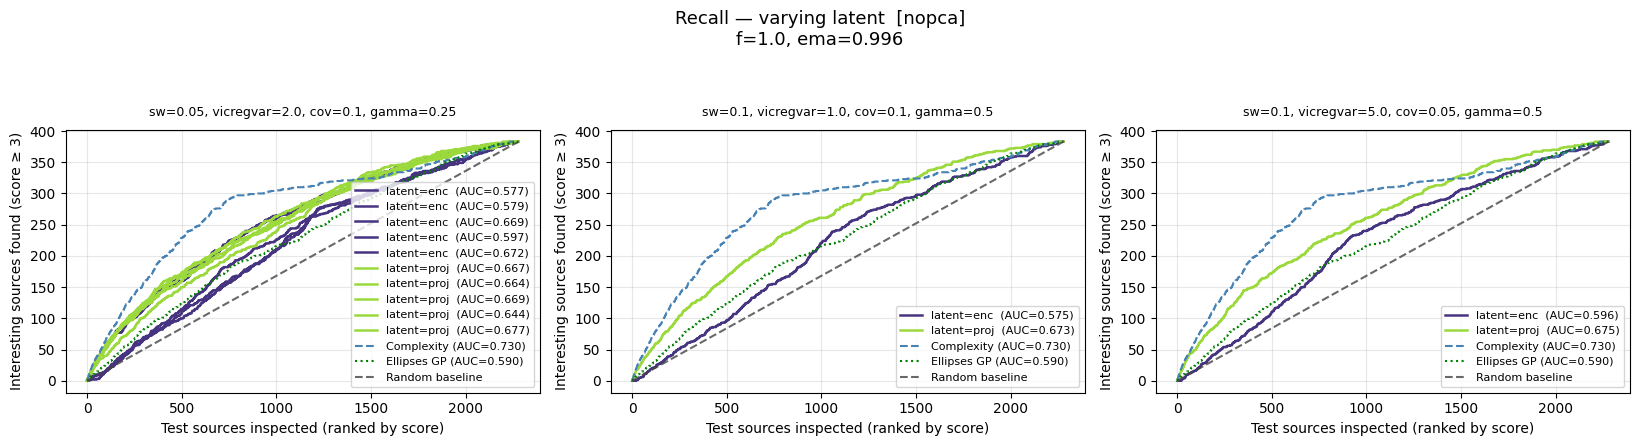

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/protege/recall_sweep_by_f_nopca.png


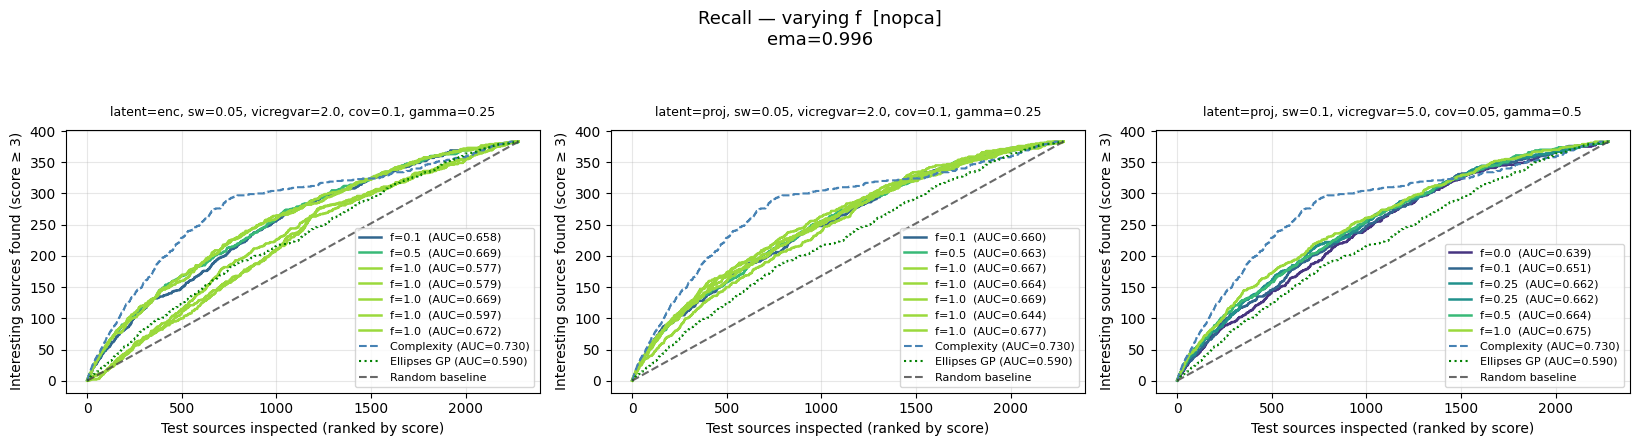

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/protege/recall_sweep_by_ema_nopca.png


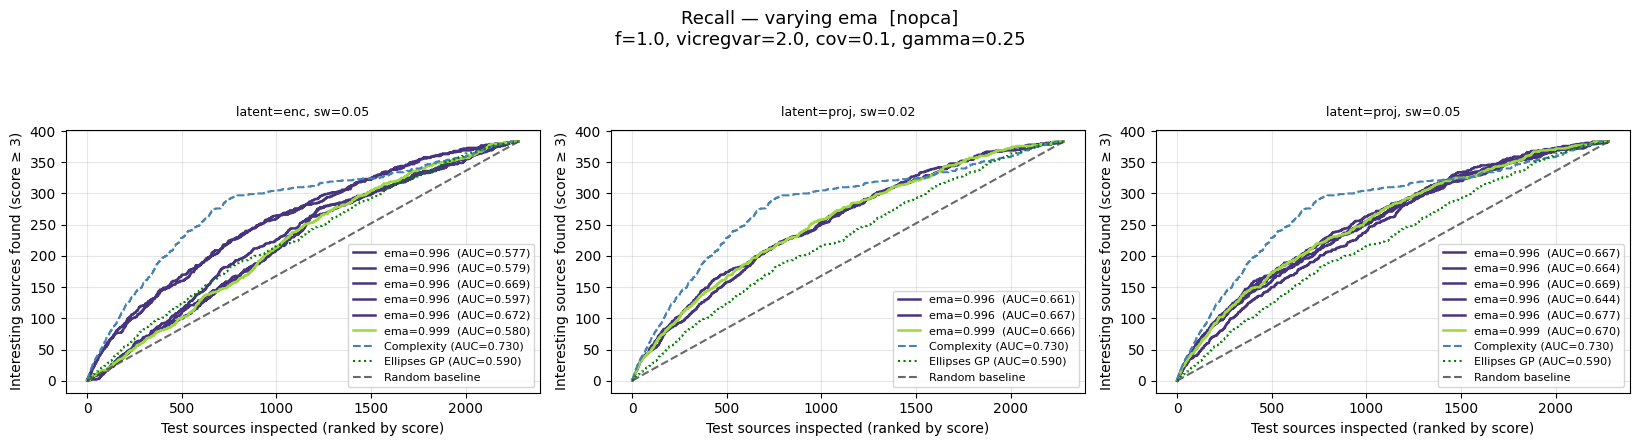

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/protege/recall_sweep_by_sw_nopca.png


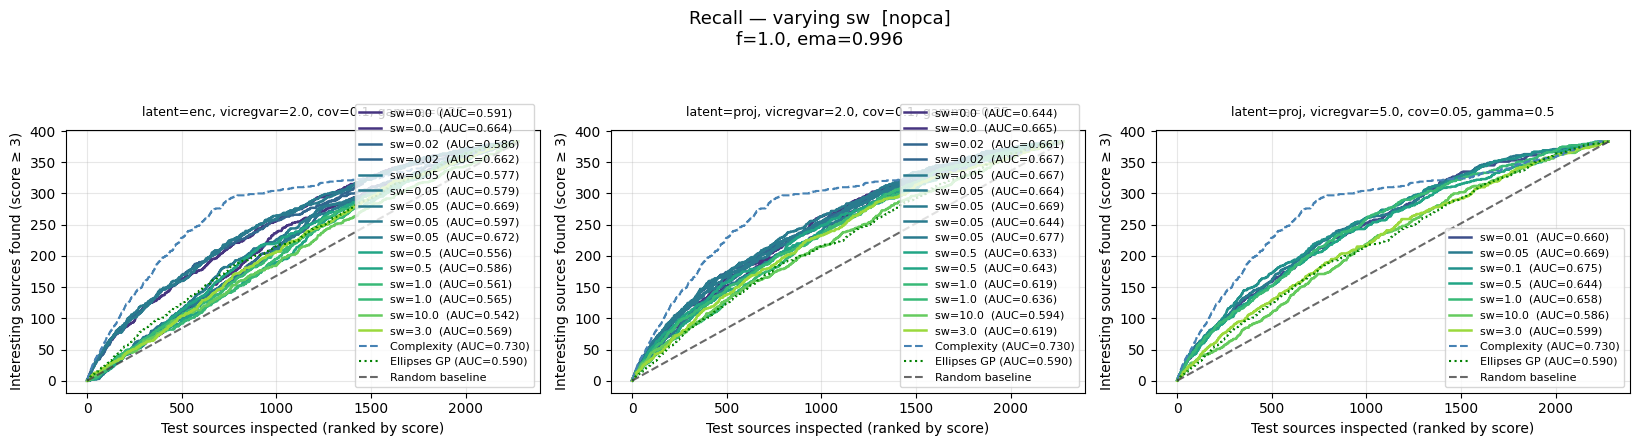

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/protege/recall_sweep_by_vicregvar_nopca.png


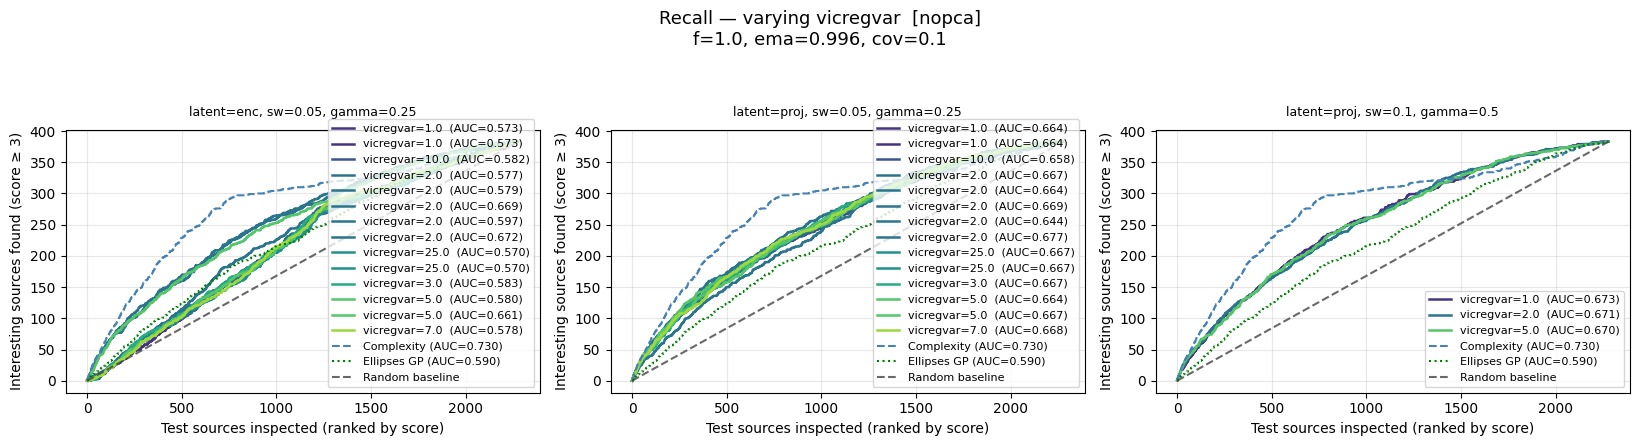

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/protege/recall_sweep_by_cov_nopca.png


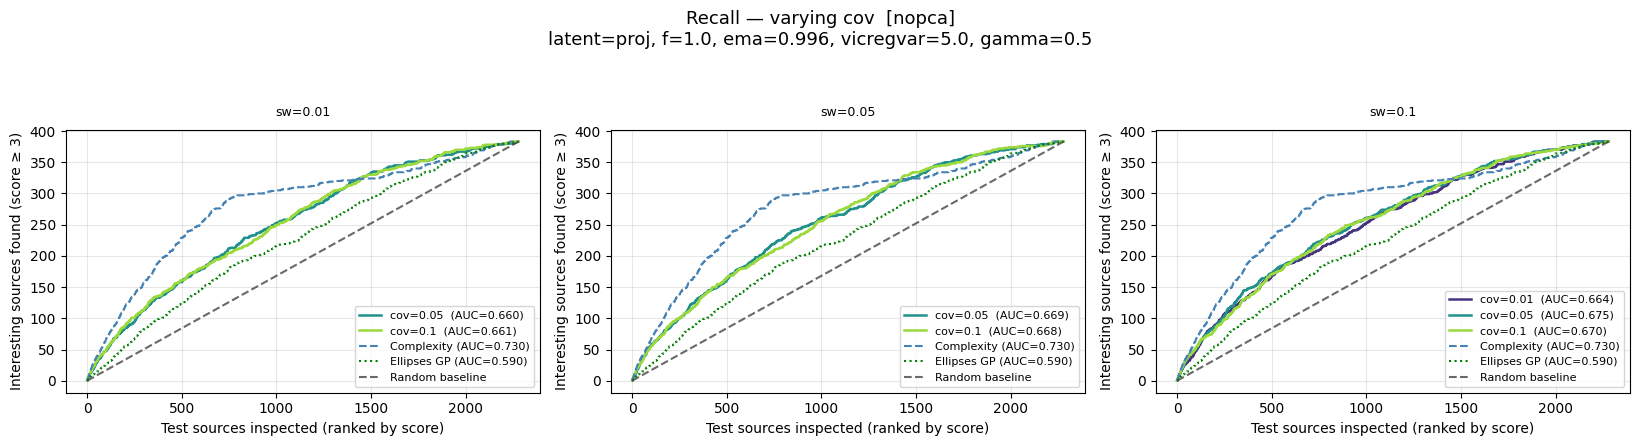

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/protege/recall_sweep_by_gamma_nopca.png


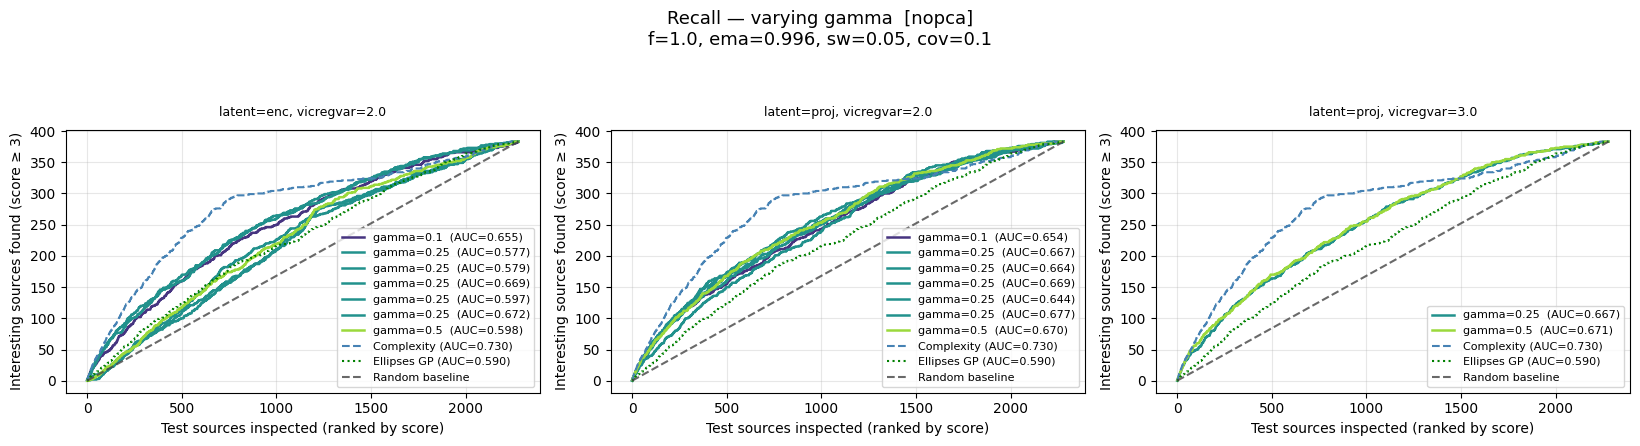


Run                                                                                                                    lat      f    ema      sw  test_AUC  train_AUC
--------------------------------------------------------------------------------------------------------------------------------------------------------------------
enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203    proj   1.00  0.996   0.050    0.6773     0.7603
enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar5_cov0.05_gamma0.5_f1_sw0.1_20260620_2158                  proj   1.00  0.996   0.100    0.6755     0.8178
enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar1_cov0.1_gamma0.5_f1_sw0.1_20260620_2022                   proj   1.00  0.996   0.100    0.6730     0.8119
enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203     enc   1.00  0.996   0.050    0.6721     0.9133
enb0

In [23]:
# ── Protege Sweep Config ──────────────────────────────────────────────────────
LABELS_PATH = LABELS_NPY_PATH   # alias
PROTEGE_PCA = "nopca"           # "nopca" = raw features, "pca" = PCA-reduced (for proj)

# Broader glob for the sweep: captures all ema values and f values.
# RUN_GLOB (Cell 3) is intentionally narrow for the single-run cells above;
# here we open it up so ema and f_label variation is visible.
SWEEP_GLOBS = [
    "enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema*_*_f*_sw*_*",
]

# Both latent types are tried for every run; whichever parquets exist are loaded.
# proj uses PROTEGE_PCA tag; enc is always PCA-reduced (1280-dim → PCA before GP).
PROTEGE_LATENTS = ["proj", "enc"]

def _latent_pca_tag(latent):
    """Return the pca suffix tag used when saving files for this latent."""
    return "pca" if latent == "enc" else PROTEGE_PCA

# ── Load all protege scores ───────────────────────────────────────────────────
_csv_df     = pd.read_csv(CSV_PATH)
_labels_all = np.load(LABELS_PATH)

def _load_test_idx(rd, data_seed):
    """Load test_idx.npy from splits dir (new runs) or data dir (old runs)."""
    p = rd.parent.parent / "data_splits" / str(data_seed) / "test_idx.npy"
    return np.load(p if p.exists() else rd / "data" / "test_idx.npy")

def _read_data_seed(rd):
    """Read data_seed from checkpoint config."""
    ckpt = torch.load(rd / "byol_model_best.pt", map_location="cpu", weights_only=False)
    return int(ckpt["config"]["data_seed"])

protege_results = []
for rd in sorted({rd for g in SWEEP_GLOBS for rd in BYOL_RUNS_ROOT.glob(g)}):
    m = re.search(r'_f([\d.]+)_sw([\d.]+)', rd.name)
    if not m:
        continue
    f_val  = float(m.group(1))
    sw_val = float(m.group(2))

    m_ema = re.search(r'_ema([\d.]+)', rd.name)
    m_vv  = re.search(r'_vicregvar([\d.]+)', rd.name)
    m_cov = re.search(r'_cov([\d.]+)',        rd.name)
    m_gam = re.search(r'_gamma([\d.]+)',       rd.name)
    ema       = float(m_ema.group(1)) if m_ema else None
    vicregvar = float(m_vv.group(1))  if m_vv  else None
    cov       = float(m_cov.group(1)) if m_cov else None
    gamma     = float(m_gam.group(1)) if m_gam else None

    # model: first token after "run_"
    m_model = re.match(r'run_(\w+)_', rd.name)
    model   = m_model.group(1) if m_model else None

    # encoder: projector type + optional pd{dim}, read up to pond/clos boundary
    m_enc = re.match(r'run_\w+_(\w+)(?:_(pd\d+))?_(pond|clos)_', rd.name)
    if m_enc:
        _proj   = m_enc.group(1)
        _pdim   = m_enc.group(2)
        aug     = m_enc.group(3)
        encoder = f"{_proj}_{_pdim}" if _pdim else _proj
    else:
        aug = encoder = None

    _protege_dir = rd / "data" / "protege"

    # Try each latent type — create a separate entry per latent that has a parquet
    for latent in PROTEGE_LATENTS:
        _ptag = _latent_pca_tag(latent)
        scores_path = summary_path = None
        # New naming: protege_scores_{latent}_{pca_tag}.parquet
        # Fallback: old single-file naming (protege_scores_{pca_tag}.parquet)
        for _sfx in [f"{latent}_{_ptag}", _ptag]:
            _sp = _protege_dir / f"protege_scores_{_sfx}.parquet"
            _su = _protege_dir / f"protege_summary_{_sfx}.json"
            if _sp.exists():
                scores_path  = _sp
                summary_path = _su if _su.exists() else None
                break

        if scores_path is None:
            continue

        active_output = pd.read_parquet(scores_path)

        if summary_path is not None:
            with open(summary_path) as fh:
                summary = json.load(fh)
            n_eval    = summary["n_eval"]
            n_pos     = summary["n_eval_positives"]
            auc       = summary.get("test_auc")
            train_auc = summary.get("train_auc")
            data_seed = summary.get("data_seed") or _read_data_seed(rd)
        else:
            data_seed = _read_data_seed(rd)
            _test_idx = _load_test_idx(rd, data_seed)
            _ldf      = pd.DataFrame(_labels_all[_test_idx].astype(bool), columns=LABEL_COLS)
            _hl       = np.ones(len(_ldf), dtype=int)
            for _sv, _cols in reversed(TIERS):
                _hl[_ldf[_cols].any(axis=1).values] = _sv
            n_eval    = len(_test_idx)
            n_pos     = int((_hl >= POSITIVE_THRESHOLD).sum())
            auc       = train_auc = None

        protege_results.append(dict(
            name=rd.name, rd=rd,
            f=f_val, sw=sw_val, ema=ema, vicregvar=vicregvar, cov=cov, gamma=gamma,
            model=model, aug=aug, encoder=encoder, latent=latent,
            active_output=active_output,
            n_eval=n_eval, n_pos=n_pos, auc=auc, train_auc=train_auc,
            data_seed=data_seed,
        ))
        auc_s = f"  auc={auc:.4f}" if auc is not None else ""
        print(f"  loaded {rd.name}  latent={latent}  (f={f_val}, sw={sw_val}){auc_s}")

print(f"\nLoaded {len(protege_results)} Protege run×latent entries.")

# ── Helpers ───────────────────────────────────────────────────────────────────
def _test_recall(r):
    """Return (x, cum, auc, n_pos) on r's test set using active_output scores."""
    test_idx    = _load_test_idx(r["rd"], r["data_seed"])
    src_names   = _csv_df.iloc[test_idx]["Source_Name"].values
    ldf         = pd.DataFrame(_labels_all[test_idx].astype(bool), columns=LABEL_COLS)
    hl          = np.ones(len(ldf), dtype=int)
    for sv, cols in reversed(TIERS):
        hl[ldf[cols].any(axis=1).values] = sv
    true_labels = pd.Series(hl, index=src_names)
    ao          = r["active_output"]
    test_srcs   = [n for n in src_names if n in ao.index]
    ranked      = ao.loc[test_srcs].sort_values("trained_score", ascending=False)
    binary      = (true_labels.loc[ranked.index] >= POSITIVE_THRESHOLD).astype(int).values
    cum         = np.cumsum(binary)
    n, n_pos_   = len(cum), int(binary.sum())
    x           = np.arange(1, n + 1)
    auc_        = float(np.trapz(cum, x) / (n * n_pos_)) if n_pos_ > 0 else 0.0
    return x, cum, auc_, n_pos_

_baselines_cache = {}
def _get_baselines(r):
    seed = r["data_seed"]
    if seed not in _baselines_cache:
        bp = OUTPUTS_ROOT / "anomaly_baselines" / f"baselines_{seed}.json"
        _baselines_cache[seed] = json.load(open(bp)) if bp.exists() else None
    return _baselines_cache[seed]

if not protege_results:
    print("No Protege scores available.")
else:
    # ── One-parameter-at-a-time sweep figures ─────────────────────────────────
    # latent, ema, and f are now first-class sweep dimensions alongside sw/vicregvar/etc.
    VARY_PARAMS = ["latent", "f", "ema", "sw", "vicregvar", "cov", "gamma", "encoder", "aug", "model"]
    _sweep_dir  = OUTPUTS_ROOT / "figures" / "protege"
    _sweep_dir.mkdir(parents=True, exist_ok=True)

    for vary_p in VARY_PARAMS:
        other_params = [p for p in VARY_PARAMS if p != vary_p]

        groups = defaultdict(list)
        for r in protege_results:
            if r[vary_p] is None:
                continue
            key = tuple(r[p] for p in other_params)
            groups[key].append(r)

        valid = {k: v for k, v in groups.items()
                 if len({r[vary_p] for r in v}) >= 2}
        if not valid:
            continue

        def _peak_auc(runs):
            vals = [r["auc"] for r in runs if r["auc"] is not None]
            return max(vals) if vals else -1.0

        if len(valid) > 3:
            valid = dict(sorted(valid.items(), key=lambda kv: -_peak_auc(kv[1]))[:3])

        # ── Split fixed params into shared (same across all groups) and differing ──
        valid_keys = list(valid.keys())
        shared_parts   = []  # go into supertitle
        differ_indices = []  # indices into other_params that vary across groups
        for pi, p in enumerate(other_params):
            vals_for_p = {k[pi] for k in valid_keys}
            if len(vals_for_p) == 1:
                v = next(iter(vals_for_p))
                if v is not None:
                    shared_parts.append(f"{p}={v}")
            else:
                differ_indices.append(pi)

        all_vals = sorted({r[vary_p] for v in valid.values() for r in v},
                          key=lambda x: str(x))
        cmap_v  = plt.cm.viridis(np.linspace(0.15, 0.85, len(all_vals)))
        val_clr = {v: cmap_v[i] for i, v in enumerate(all_vals)}

        n_groups = len(valid)
        ncols    = min(n_groups, 3)
        nrows    = (n_groups + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols,
                                  figsize=(ncols * 5.5, nrows * 4.5), sharey=False)
        axes = np.array(axes).reshape(nrows, ncols)

        for ax_i, (fixed_key, group) in enumerate(sorted(valid.items(), key=str)):
            ax = axes[ax_i // ncols, ax_i % ncols]

            # Only show params that differ between subfigures
            differ_parts = [f"{other_params[pi]}={fixed_key[pi]}"
                            for pi in differ_indices if fixed_key[pi] is not None]
            ax.set_title(", ".join(differ_parts) if differ_parts else vary_p,
                         fontsize=9, pad=10)

            for r in sorted(group, key=lambda x: str(x[vary_p])):
                x, cum, auc_, _ = _test_recall(r)
                ax.plot(x, cum, color=val_clr[r[vary_p]], linewidth=1.8,
                        label=f"{vary_p}={r[vary_p]}  (AUC={auc_:.3f})")

            r0  = group[0]
            bl  = _get_baselines(r0)
            n_  = r0["n_eval"]
            np_ = r0["n_pos"]

            if bl:
                ax.plot(bl["complexity"]["x"], bl["complexity"]["recall"],
                        color="steelblue", linewidth=1.5, linestyle="--",
                        label=f"Complexity (AUC={bl['complexity']['auc']:.3f})")
                if bl.get("ellipses_gp"):
                    ax.plot(bl["ellipses_gp"]["x"], bl["ellipses_gp"]["recall"],
                            color="green", linewidth=1.5, linestyle=":",
                            label=f"Ellipses GP (AUC={bl['ellipses_gp']['auc']:.3f})")

            ax.plot(np.arange(1, n_ + 1), np.arange(1, n_ + 1) * (np_ / n_),
                    color="#444444", linestyle="--", linewidth=1.5, alpha=0.8,
                    label="Random baseline")

            ax.set_xlabel("Test sources inspected (ranked by score)")
            ax.set_ylabel(f"Interesting sources found (score ≥ {POSITIVE_THRESHOLD})")
            ax.legend(fontsize=8, loc="lower right")
            ax.grid(True, alpha=0.3)

        for idx in range(n_groups, nrows * ncols):
            axes[idx // ncols, idx % ncols].set_visible(False)

        # Supertitle: varying param + shared fixed params on a second line
        suptitle = f"Recall — varying {vary_p}  [{PROTEGE_PCA}]"
        if shared_parts:
            suptitle += "\n" + ", ".join(shared_parts)
        fig.suptitle(suptitle, fontsize=13)
        plt.tight_layout(rect=[0, 0, 1, 0.92])
        _out = _sweep_dir / f"recall_sweep_by_{vary_p}_{PROTEGE_PCA}.png"
        fig.savefig(_out, dpi=150, bbox_inches="tight")
        print(f"Saved → {_out}")
        plt.show()

    # ── AUC summary table ──────────────────────────────────────────────────────
    if any(r["auc"] is not None for r in protege_results):
        w = max(len(r["name"]) for r in protege_results)
        print(f"\n{'Run':<{w}}  {'lat':>4}  {'f':>5}  {'ema':>5}  {'sw':>6}  {'test_AUC':>8}  {'train_AUC':>9}")
        print("-" * (w + 48))
        for r in sorted(protege_results, key=lambda x: -(x["auc"] or 0)):
            auc_s  = f"{r['auc']:>8.4f}"      if r["auc"]       is not None else "     N/A"
            tauc_s = f"{r['train_auc']:>9.4f}" if r["train_auc"] is not None else "      N/A"
            print(f"{r['name']:<{w}}  {r['latent']:>4}  {r['f']:>5.2f}  "
                  f"{str(r['ema']):>5}  {r['sw']:>6.3f}  {auc_s}  {tauc_s}")


## Noise Robustness Test

Evaluates BYOL GP and Ellipses GP on test images with injected Gaussian noise. Real-valued Gaussian noise is Hermitian-symmetric in Fourier space, matching the statistical structure of interferometric noise.

Noise is parameterised as a multiple σ of each source image's own pixel standard deviation, making it scale-invariant across the dataset. The GP is trained once on clean training data and then scored on noisy test features at each σ — equivalent to testing degraded observing conditions without retraining.

**Complexity (featurecount) is not included**: re-running PyBDSF on noisy images requires a batch job. Once noisy featurecounts are available they can be added to `_nr_results` and the plot cell.

In [ ]:
# ── Noise robustness test ─────────────────────────────────────────────────────
# σ=0: BYOL AUC is read from the pre-computed Protege parquet; Ellipses AUC
#       from the nb ellipses GP cache (cell 34).  No re-encoding at σ=0.
# σ>0: BYOL is re-encoded with the checkpoint (images /255 before encode);
#       Ellipses features are loaded from the on-disk noise parquets (already
#       computed by a previous notebook run) and NaN rows are imputed with
#       per-column train medians (no -inf ranking).
# Results are cached to noise_robustness.json so rerunning is instant.

NOISE_SIGMAS = [0.0, 0.25, 0.5, 1.0, 2.0]
_nr_json = Path(RUN_DIR) / "noise_robustness" / "noise_robustness.json"

def _nr_recall_auc(scores, true_labels, pos_thresh=POSITIVE_THRESHOLD):
    order  = np.argsort(scores)[::-1]
    binary = (true_labels[order] >= pos_thresh).astype(int)
    cum    = np.cumsum(binary)
    n_pos  = int(binary.sum())
    x      = np.arange(1, len(cum) + 1)
    return float(np.trapz(cum, x) / (len(cum) * n_pos)) if n_pos > 0 else 0.0

_nr_data = None
if _nr_json.exists():
    with open(_nr_json) as _fh:
        _nr_data = json.load(_fh)
    print(f"Loaded cached noise robustness results from {_nr_json.name}")

if _nr_data is None:
    # ── σ=0 BYOL AUC: read directly from Protege parquet ─────────────────────
    # Avoids dependency on test_output (cell 28/36 in-memory state).
    _nr_byol_parquet = Path(RUN_DIR) / "protege" / f"protege_scores_{_latent_tag}.parquet"
    _nr_byol_df = pd.read_parquet(_nr_byol_parquet)
    _nr_byol0 = _nr_recall_auc(_nr_byol_df.loc[_test_names, "trained_score"].values, _test_human)

    # ── σ=0 Ellipses AUC: read directly from nb ellipses GP parquet ──────────
    # Avoids dependency on _ell_gp_nb_test (cell 34 in-memory state).
    _nr_ell_parquet = _nb_protege_dir / f"ellipses_gp_nb_q{n_train}.parquet"
    if _nr_ell_parquet.exists():
        _nr_ell_df = pd.read_parquet(_nr_ell_parquet)
        _nr_test_ell_scores = _nr_ell_df[_nr_ell_df["split"] == "test"]["trained_score"].values
        _nr_ell0 = _nr_recall_auc(_nr_test_ell_scores, _test_human)
    elif _ell_gp_nb_test is not None:
        _nr_ell0 = _nr_recall_auc(_ell_gp_nb_test.values, _test_human)
    else:
        print("WARNING: ellipses GP parquet not found and _ell_gp_nb_test not set — run cell 34 first.")
        _nr_ell0 = float("nan")

    # ── BYOL encoder + sklearn GP (for σ>0) ───────────────────────────────────
    _nr_ckpt = torch.load(_run_dir_root / "byol_model_best.pt",
                          map_location="cpu", weights_only=False)
    _nr_model = BYOLEfficientNetB0(
        projection_dim=_nr_ckpt["config"].get("projection_dim", 256),
        hidden_dim=_nr_ckpt["config"].get("hidden_dim", 4096),
    )
    _nr_sd = _nr_ckpt["model_state_dict"]
    if any(k.startswith("_orig_mod.") for k in _nr_sd):
        _nr_sd = {k.removeprefix("_orig_mod."): v for k, v in _nr_sd.items()}
    _nr_model.load_state_dict(_nr_sd, strict=False)
    _nr_model.eval()
    _nr_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _nr_model   = _nr_model.to(_nr_device)

    def _nr_encode(images_01, batch_size=64):
        """Encode (N, H, W) float32 images in [0, 1] range → (N, D) numpy.

        Images MUST be in [0, 1] — the BYOL backbone was trained on images
        loaded as .astype(float32)/255 (see train_byol.py line 404).
        """
        out = []
        with torch.no_grad():
            for i in range(0, len(images_01), batch_size):
                x = torch.from_numpy(images_01[i:i+batch_size]).unsqueeze(1).float().to(_nr_device)
                out.append(_nr_model.online_encoder(x).float().cpu().numpy())
        return np.vstack(out)

    # BYOL GP: fit sklearn GP on PCA-reduced train features using Protege labels.
    # active_output (from cell 28) has human_label for all queried train sources.
    _nr_labeled  = active_output["human_label"] > 0
    _nr_X_byol   = features_train[_nr_labeled].values
    _nr_y_byol   = active_output.loc[_nr_labeled, "human_label"].values.astype(float)
    _nr_gpr_byol = GaussianProcessRegressor(
        kernel=Matern(length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level_bounds=(1e-3, 1e1)),
        normalize_y=True,
    )
    _nr_gpr_byol.fit(_nr_X_byol, _nr_y_byol)
    print(f"BYOL GP fitted: {_nr_labeled.sum()} labeled train sources")

    # Ellipses GP: fit sklearn GP with median imputation (matches cell 34 design).
    _nr_tr_ell       = _all_ell.iloc[idx_arr].copy()
    _nr_tr_ell.index = source_names
    _nr_tr_nan       = _nr_tr_ell.isna().any(axis=1)
    _nr_tr_medians   = _nr_tr_ell[~_nr_tr_nan].median()   # train medians — no test leakage
    _nr_tr_ell_imp   = _nr_tr_ell.fillna(_nr_tr_medians)
    _nr_y_ell        = labels_df.loc[_nr_tr_ell_imp.index, "human_label"].values.astype(float)
    _nr_scaler_ell   = StandardScaler()
    _nr_tr_scaled    = _nr_scaler_ell.fit_transform(_nr_tr_ell_imp.values)
    _nr_gpr_ell      = GaussianProcessRegressor(
        kernel=Matern(length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level_bounds=(1e-3, 1e1)),
        normalize_y=True,
    )
    _nr_gpr_ell.fit(_nr_tr_scaled, _nr_y_ell)
    print(f"Ellipses GP fitted: {len(_nr_tr_ell_imp)} train sources "
          f"(imputed {int(_nr_tr_nan.sum())} NaN rows)")

    # ── Noise sweep ───────────────────────────────────────────────────────────
    _nr_test_imgs = np.load(IMAGES_PATH)[_test_idx]   # raw uint8, (N_test, H, W)
    _nr_rng       = np.random.default_rng(42)

    def _nr_add_noise(images, sigma_rel):
        """Add Gaussian noise scaled by per-image std (in raw pixel space)."""
        if sigma_rel == 0.0:
            return images.astype(np.float32)
        per_img_std = images.astype(np.float32).std(axis=(-2, -1), keepdims=True).clip(1e-6)
        return (images.astype(np.float32)
                + _nr_rng.normal(0.0, sigma_rel, images.shape).astype(np.float32) * per_img_std)

    _nr_byol_auc = []
    _nr_ell_auc  = []

    for sigma in NOISE_SIGMAS:
        print(f"σ={sigma} ...", end=" ", flush=True)

        if sigma == 0.0:
            # Use pre-computed parquet scores — no re-encoding needed
            _nr_byol_auc.append(_nr_byol0)
            _nr_ell_auc.append(_nr_ell0)
            print(f"BYOL={_nr_byol0:.3f}  Ell={_nr_ell0:.3f}  (from parquet/cache)")
            continue

        noisy_imgs = _nr_add_noise(_nr_test_imgs, sigma)

        # BYOL: divide by 255 before encoding (matches train_byol.py normalisation)
        noisy_enc     = _nr_encode(noisy_imgs / 255.0)
        noisy_enc_pca = pca.transform(noisy_enc) if APPLY_PCA and "pca" in dir() else noisy_enc
        byol_scores   = _nr_gpr_byol.predict(noisy_enc_pca)
        _nr_byol_auc.append(_nr_recall_auc(byol_scores, _test_human))

        # Ellipses: load existing parquet (computed by a previous notebook run),
        # impute NaN with train medians, score via sklearn GP.
        _nr_ell_dir         = OUTPUTS_ROOT / "noise_robustness" / f"ell_sigma{sigma}"
        _nr_ell_dir.mkdir(parents=True, exist_ok=True)
        _nr_ell_parquet_noisy = _nr_ell_dir / "EllipseFitFeatures_output.parquet"
        if _nr_ell_parquet_noisy.exists():
            _nr_noisy_ell = pd.read_parquet(_nr_ell_parquet_noisy)
        else:
            # Parquet not present — extract features and save (only happens once).
            noisy_imgs_01  = noisy_imgs / 255.0
            _nr_noisy_ds   = _NumpyImageDataset(noisy_imgs_01, output_dir=str(_nr_ell_dir), force_rerun=False)
            _nr_noisy_ext  = _sf.EllipseFitFeatures(percentiles=[90, 80, 70, 60, 50, 0], channel=0,
                                                     output_dir=str(_nr_ell_dir), force_rerun=False,
                                                     upper_limit=150)
            _nr_noisy_ell  = _nr_noisy_ext.run_on_dataset(_nr_noisy_ds)

        _nr_te_nan    = _nr_noisy_ell.isna().any(axis=1)
        _nr_noisy_imp = _nr_noisy_ell.fillna(_nr_tr_medians)    # impute NaN with train medians
        ell_scores    = _nr_gpr_ell.predict(_nr_scaler_ell.transform(_nr_noisy_imp.values))
        _nr_ell_auc.append(_nr_recall_auc(ell_scores, _test_human))
        print(f"BYOL={_nr_byol_auc[-1]:.3f}  Ell={_nr_ell_auc[-1]:.3f}  "
              f"(Ell NaN: {int(_nr_te_nan.sum())}/{len(_nr_noisy_ell)})")

    # ── Complexity reference (σ=0 only) ───────────────────────────────────────
    _nr_comp = (float(_comp_test_aucs[_BOLD_SEED])
                if "_comp_test_aucs" in dir() and _BOLD_SEED in _comp_test_aucs
                else None)

    _nr_data = {
        "noise_sigmas":    NOISE_SIGMAS,
        "byol_auc":        _nr_byol_auc,
        "ell_auc":         _nr_ell_auc,
        "comp_auc_seed42": _nr_comp,
    }
    _nr_json.parent.mkdir(parents=True, exist_ok=True)
    with open(_nr_json, "w") as _fh:
        json.dump(_nr_data, _fh, indent=2)
    print(f"Saved → {_nr_json}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(_nr_data["noise_sigmas"], _nr_data["byol_auc"], "o-", color="orange",
        linewidth=2, label="BYOL GP")
ax.plot(_nr_data["noise_sigmas"], _nr_data["ell_auc"],  "s-", color="green",
        linewidth=2, label="Ellipses GP")
ax.axhline(0.5, color="#888888", linestyle="--", linewidth=1.2, label="Random baseline")
if _nr_data.get("comp_auc_seed42"):
    ax.axhline(_nr_data["comp_auc_seed42"], color="steelblue", linestyle=":", linewidth=1.2,
               label=f"Complexity σ=0 (AUC={_nr_data['comp_auc_seed42']:.3f})")
ax.set_xlabel("Noise level σ (× per-image std)", fontsize=13)
ax.set_ylabel("Recall-curve AUC", fontsize=13)
ax.set_title("Noise Robustness — Test Set", fontsize=13)
ax.set_ylim([0, 1])
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
_nr_fig_dir = OUTPUTS_ROOT / "figures" / "noise_robustness"
_nr_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_nr_fig_dir / "auc_vs_noise.png", dpi=150, bbox_inches="tight")
plt.show()


Best enc run:  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203
  AUC=0.6721  f=1.0  sw=0.05
  Fixed: {'ema': 0.996, 'vicregvar': 2.0, 'cov': 0.1, 'gamma': 0.25}


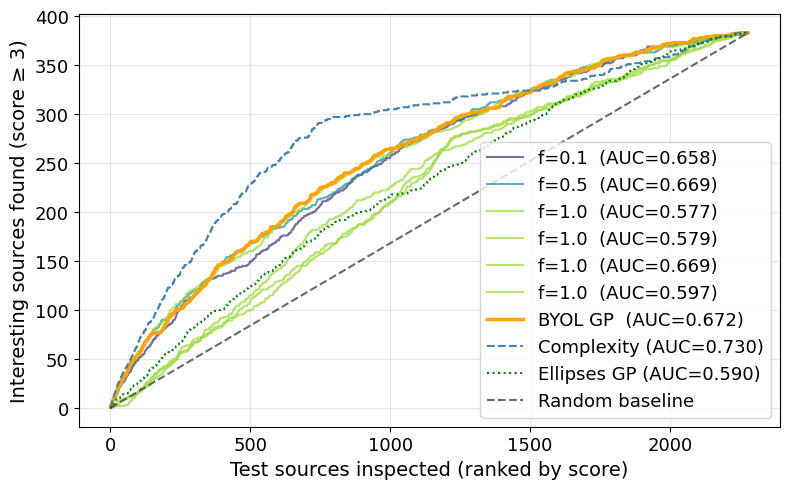

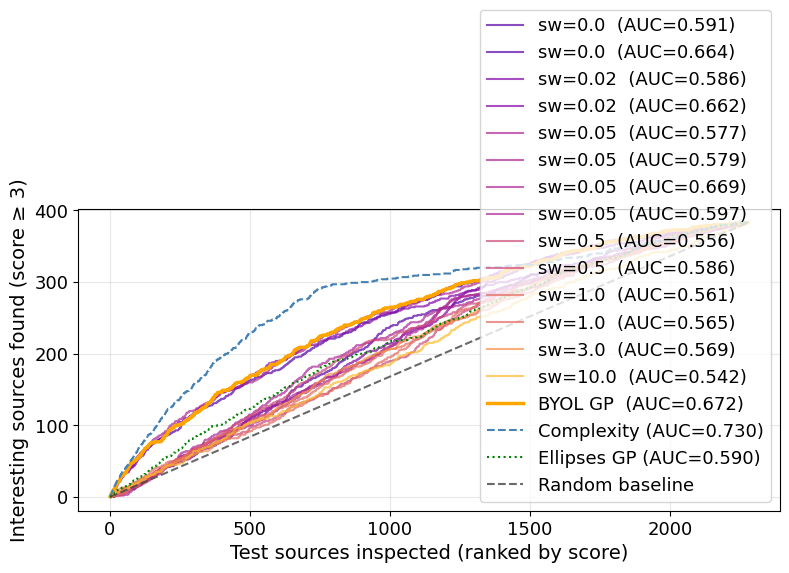

In [24]:
# ── Best enc run ablation: vary f (fig 1) and vary sw (fig 2) ────────────────
# Picks the single best enc run by test AUC, fixes its (ema, vicregvar, cov, gamma),
# then plots all available f values (at the best sw) and all sw values (at the best f).

_enc_results = [r for r in protege_results if r["latent"] == "enc" and r["auc"] is not None]
if not _enc_results:
    print("No enc results with AUC available — run the sweep cell first.")
else:
    _best = max(_enc_results, key=lambda r: r["auc"])
    _fixed_keys = ("ema", "vicregvar", "cov", "gamma")
    _fixed_vals = {k: _best[k] for k in _fixed_keys}
    print(f"Best enc run:  {_best['name']}")
    print(f"  AUC={_best['auc']:.4f}  f={_best['f']}  sw={_best['sw']}")
    print(f"  Fixed: {_fixed_vals}")

    _candidates = [
        r for r in protege_results
        if r["latent"] == "enc" and all(r[k] == _fixed_vals[k] for k in _fixed_keys)
    ]

    bl = _get_baselines(_best)

    def _ablation_plot(runs, vary_key, cmap):
        """One recall figure: best BYOL run in orange + coloured lines per vary_key value."""
        best_r  = max(runs, key=lambda r: r["auc"])
        other_r = [r for r in runs if r is not best_r]

        vals   = sorted({r[vary_key] for r in other_r}, key=float)
        colors = cmap(np.linspace(0.15, 0.85, max(len(vals), 1)))
        clr    = {v: colors[i] for i, v in enumerate(vals)}

        fig, ax = plt.subplots(figsize=(8, 5))

        # Other runs (coloured, thinner)
        for r in sorted(other_r, key=lambda x: float(x[vary_key])):
            x, cum, auc_, _ = _test_recall(r)
            ax.plot(x, cum, color=clr[r[vary_key]], linewidth=1.5, alpha=0.7,
                    label=f"{vary_key}={r[vary_key]}  (AUC={auc_:.3f})")

        # Best run: orange, labelled "BYOL GP", drawn last (on top)
        x_b, cum_b, auc_b, _ = _test_recall(best_r)
        ax.plot(x_b, cum_b, color="orange", linewidth=2.5,
                label=f"BYOL GP  (AUC={auc_b:.3f})")

        n_, np_ = runs[0]["n_eval"], runs[0]["n_pos"]

        if bl:
            ax.plot(bl["complexity"]["x"], bl["complexity"]["recall"],
                    color="steelblue", linewidth=1.5, linestyle="--",
                    label=f"Complexity (AUC={bl['complexity']['auc']:.3f})")
            if bl.get("ellipses_gp"):
                ax.plot(bl["ellipses_gp"]["x"], bl["ellipses_gp"]["recall"],
                        color="green", linewidth=1.5, linestyle=":",
                        label=f"Ellipses GP (AUC={bl['ellipses_gp']['auc']:.3f})")

        ax.plot(np.arange(1, n_ + 1), np.arange(1, n_ + 1) * (np_ / n_),
                color="#444444", linestyle="--", linewidth=1.5, alpha=0.8,
                label="Random baseline")

        ax.set_xlabel("Test sources inspected (ranked by score)", fontsize=14)
        ax.set_ylabel(f"Interesting sources found (score ≥ {POSITIVE_THRESHOLD})", fontsize=14)
        ax.tick_params(labelsize=13)
        ax.legend(fontsize=13, loc="lower right")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()

        _fig_dir = OUTPUTS_ROOT / "figures" / "protege"
        _fig_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(_fig_dir / f"best_enc_vary_{vary_key}.png", dpi=150, bbox_inches="tight")
        plt.show()

    # Figure 1: vary f — fix sw to the best run's sw
    _f_runs = [r for r in _candidates if r["sw"] == _best["sw"]]
    if _f_runs:
        _ablation_plot(_f_runs, "f", plt.cm.viridis)

    # Figure 2: vary sw — fix f to the best run's f
    _sw_runs = [r for r in _candidates if r["f"] == _best["f"]]
    if _sw_runs:
        _ablation_plot(_sw_runs, "sw", plt.cm.plasma)


f-ablation group: sw=0.05  ema=0.996  vicregvar=2.0  cov=0.1  gamma=0.25
  f values: [0.1, 0.5, 1.0]


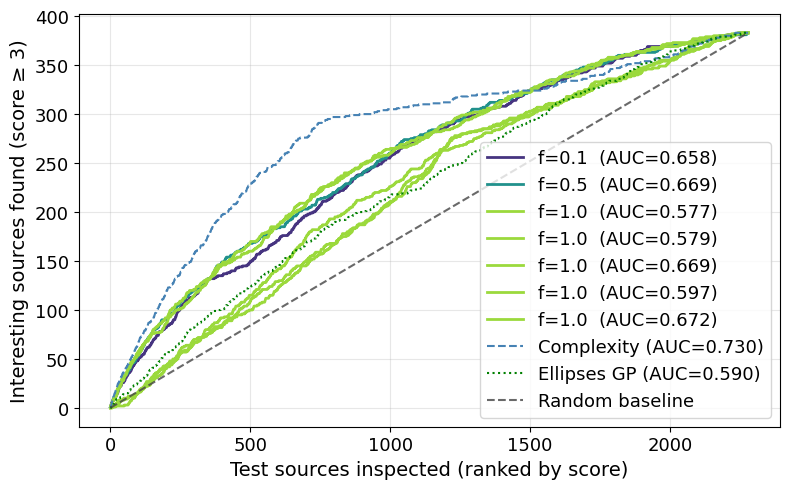

sw-ablation group: f=1.0  ema=0.996  vicregvar=2.0  cov=0.1  gamma=0.25
  sw values: [0.0, 0.02, 0.05, 0.5, 1.0, 3.0, 10.0]


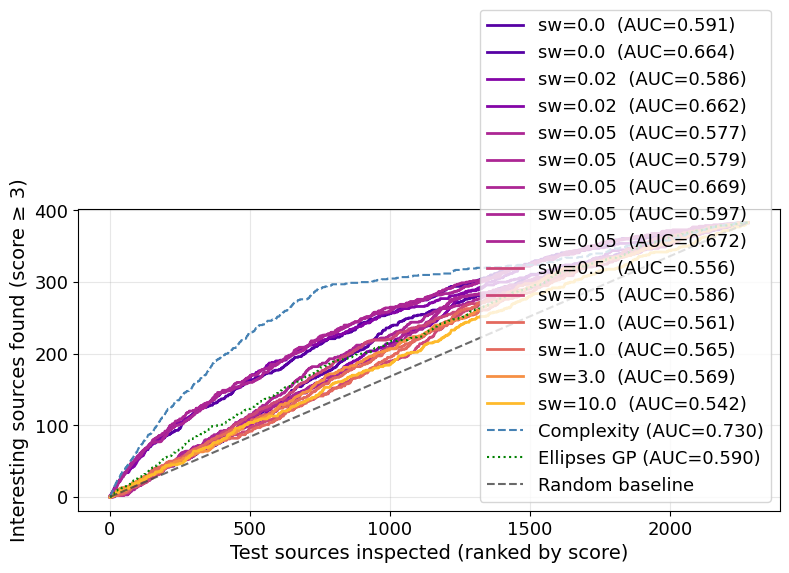

In [25]:
# ── Ablation: vary f / sw — require ≥ 3 distinct values ──────────────────────
# For each varying key, search all (ema, vicregvar, cov, gamma, <other key>)
# groups that have ≥ 3 distinct values of the key.  Pick the group whose
# best-AUC run has the highest AUC, then plot.

_MIN_VALS = 3   # minimum distinct values to qualify

def _best_group(vary_key, fix_sw_or_f_key):
    """Return (runs, group_key_dict) for the qualifying group with highest best-AUC."""
    group_keys = ("ema", "vicregvar", "cov", "gamma", fix_sw_or_f_key)
    enc_runs = [r for r in protege_results if r["latent"] == "enc" and r["auc"] is not None]
    groups = {}
    for r in enc_runs:
        key = tuple(r[k] for k in group_keys)
        groups.setdefault(key, []).append(r)
    qualifying = {k: v for k, v in groups.items() if len({r[vary_key] for r in v}) >= _MIN_VALS}
    if not qualifying:
        return None, None
    best_key = max(qualifying, key=lambda k: max(r["auc"] for r in qualifying[k]))
    return qualifying[best_key], dict(zip(group_keys, best_key))

def _ablation_plot2(runs, vary_key, cmap, bl2):
    vals   = sorted({r[vary_key] for r in runs}, key=float)
    colors = cmap(np.linspace(0.15, 0.85, len(vals)))
    clr    = {v: colors[i] for i, v in enumerate(vals)}
    fig, ax = plt.subplots(figsize=(8, 5))
    for r in sorted(runs, key=lambda x: float(x[vary_key])):
        x, cum, auc_, _ = _test_recall(r)
        ax.plot(x, cum, color=clr[r[vary_key]], linewidth=2,
                label=f"{vary_key}={r[vary_key]}  (AUC={auc_:.3f})")
    n_, np_ = runs[0]["n_eval"], runs[0]["n_pos"]
    if bl2:
        ax.plot(bl2["complexity"]["x"], bl2["complexity"]["recall"],
                color="steelblue", linewidth=1.5, linestyle="--",
                label=f"Complexity (AUC={bl2['complexity']['auc']:.3f})")
        if bl2.get("ellipses_gp"):
            ax.plot(bl2["ellipses_gp"]["x"], bl2["ellipses_gp"]["recall"],
                    color="green", linewidth=1.5, linestyle=":",
                    label=f"Ellipses GP (AUC={bl2['ellipses_gp']['auc']:.3f})")
    ax.plot(np.arange(1, n_ + 1), np.arange(1, n_ + 1) * (np_ / n_),
            color="#444444", linestyle="--", linewidth=1.5, alpha=0.8,
            label="Random baseline")
    ax.set_xlabel("Test sources inspected (ranked by score)", fontsize=14)
    ax.set_ylabel(f"Interesting sources found (score ≥ {POSITIVE_THRESHOLD})", fontsize=14)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=13, loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _fig_dir = OUTPUTS_ROOT / "figures" / "protege"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_fig_dir / f"best_group_vary_{vary_key}.png", dpi=150, bbox_inches="tight")
    plt.show()

_enc_results = [r for r in protege_results if r["latent"] == "enc" and r["auc"] is not None]
if not _enc_results:
    print("No enc results with AUC available — run the sweep cell first.")
else:
    # Figure 1: vary f with ≥ 3 distinct f values
    _f_group, _f_gk = _best_group("f", "sw")
    if _f_group:
        _bl_f = _get_baselines(max(_f_group, key=lambda r: r["auc"]))
        print(f"f-ablation group: sw={_f_gk['sw']}  ema={_f_gk['ema']}  "
              f"vicregvar={_f_gk['vicregvar']}  cov={_f_gk['cov']}  gamma={_f_gk['gamma']}")
        print(f"  f values: {sorted({r['f'] for r in _f_group})}")
        _ablation_plot2(_f_group, "f", plt.cm.viridis, _bl_f)
    else:
        print(f"No enc group has ≥ {_MIN_VALS} distinct f values.")

    # Figure 2: vary sw with ≥ 3 distinct sw values
    _sw_group, _sw_gk = _best_group("sw", "f")
    if _sw_group:
        _bl_sw = _get_baselines(max(_sw_group, key=lambda r: r["auc"]))
        print(f"sw-ablation group: f={_sw_gk['f']}  ema={_sw_gk['ema']}  "
              f"vicregvar={_sw_gk['vicregvar']}  cov={_sw_gk['cov']}  gamma={_sw_gk['gamma']}")
        print(f"  sw values: {sorted({r['sw'] for r in _sw_group})}")
        _ablation_plot2(_sw_group, "sw", plt.cm.plasma, _bl_sw)
    else:
        print(f"No enc group has ≥ {_MIN_VALS} distinct sw values.")

## Interactive Protege Fine-Tuning

Select one run from the sweep results, warm-start the GP from its existing labels,
and continue active learning interactively. The final recall curve shows both the
original sweep result and the interactively fine-tuned result on their respective
evaluation sets (sources never queried by either phase).

In [26]:
raise SystemExit("Stop here — interactive fine-tuning section below.")

SystemExit: Stop here — interactive fine-tuning section below.

/users/mbredber/.venv/lib64/python3.11/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### Fine-Tune Run Selection and Initialisation

Selects a specific run from `protege_results` by name, loads its existing Protege sweep scores, and reconstructs the PCA-reduced feature matrix and image arrays needed to warm-start the interactive GP session.

In [ ]:
# ── Select which run to fine-tune ────────────────────────────────────────────
FINETUNE_RUN_NAME = "run_no_val_run_f0.5_sw3_20260521_1904"  # edit to pick a run (f≠1)
PROTEGE_SUFFIX    = ""   # must match the suffix used in run_protege_sweep.py

# ── Load the selected run's sweep results ────────────────────────────────────
_ft_run = next((r for r in protege_results if r["name"] == FINETUNE_RUN_NAME), None)
assert _ft_run is not None, (
    f"Run '{FINETUNE_RUN_NAME}' not found in protege_results. "
    f"Available: {[r['name'] for r in protege_results]}"
)

_suffix      = f"_{PROTEGE_SUFFIX}" if PROTEGE_SUFFIX else ""
_scores_path = OUTPUTS_ROOT / FINETUNE_RUN_NAME / "protege" / f"protege_scores{_suffix}.parquet"
_sweep_ao    = pd.read_parquet(_scores_path)

# ── Reconstruct features_pca (mirrors train_protege_list.py logic) ────────────
_ft_run_dir = OUTPUTS_ROOT / FINETUNE_RUN_NAME
_data_dir   = _ft_run_dir / "data"
_ckpt_ft    = torch.load(_ft_run_dir / "byol_model_best.pt", map_location="cpu", weights_only=False)
_seed_ft    = int(_ckpt_ft["config"]["data_seed"])
_splits_ft  = _ft_run_dir.parent / "data_splits" / str(_seed_ft)

def _load_ft_idx(name):
    p = _splits_ft / name
    return np.load(p if p.exists() else _data_dir / name)

_lab_idx    = _load_ft_idx("labelled_train_idx.npy")
_unlab_idx  = _load_ft_idx("unlabelled_train_idx.npy")

_lab_proj        = np.load(_data_dir / "labelled_train_projections.npy")
_unlab_proj_path = _data_dir / "unlabelled_train_projections.npy"
if _unlab_proj_path.exists() and len(_lab_idx) > 0 and len(_unlab_idx) > 0:
    _unlab_proj = np.load(_unlab_proj_path)
    _all_proj   = np.concatenate([_lab_proj, _unlab_proj], axis=0)
    _all_idx    = np.concatenate([_lab_idx, _unlab_idx])
elif len(_lab_idx) == 0:   # f=0
    _all_proj = _lab_proj
    _all_idx  = _unlab_idx
else:                       # f=1
    _all_proj = _lab_proj
    _all_idx  = _lab_idx

_csv        = pd.read_csv(CSV_PATH)
_src_names  = _csv.iloc[_all_idx]["Source_Name"].values

_proj_scaled = StandardScaler().fit_transform(_all_proj)
_pca_model   = PCA(n_components=0.95, svd_solver="full")
_proj_pca    = _pca_model.fit_transform(_proj_scaled)
ft_features  = pd.DataFrame(_proj_pca, index=_src_names)
print(f"Features: {ft_features.shape}")

# ── Reconstruct true labels ───────────────────────────────────────────────────
_labels_all  = np.load(LABELS_PATH)
_ldf         = pd.DataFrame(_labels_all[_all_idx].astype(bool), columns=LABEL_COLS)
_hl          = np.ones(len(_ldf), dtype=int)
for _sv, _cols in reversed(TIERS):
    _hl[_ldf[_cols].any(axis=1).values] = _sv
ft_true_labels = pd.Series(_hl, index=_src_names)

# ── Record original sweep eval set (human_label == -1 in parquet) ────────────
_sweep_eval_mask = _sweep_ao["human_label"] == -1
_sweep_eval_srcs = set(_sweep_ao[_sweep_eval_mask].index)
n_sweep_eval     = len(_sweep_eval_srcs)
n_sweep_pos      = int((ft_true_labels.loc[list(_sweep_eval_srcs)] >= POSITIVE_THRESHOLD).sum())
print(f"Sweep eval set: {n_sweep_eval} sources, {n_sweep_pos} positives")

# ── Images for interactive display ───────────────────────────────────────────
_images_all    = np.load(IMAGES_PATH)
_ft_images     = _images_all[_all_idx]
_ft_src_to_pos = {src: i for i, src in enumerate(_src_names)}


AssertionError: Run 'run_no_val_run_f0.5_sw3_20260521_1904' not found in protege_results. Available: ['enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar10_cov0.1_gamma1.0_f1_sw0.1_20260619_1428', 'enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar10_cov0.1_gamma1.0_f1_sw0.1_20260619_1428', 'enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar10_cov0.1_gamma1.0_f1_sw0.5_20260619_1517', 'enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar10_cov0.1_gamma1.0_f1_sw0.5_20260619_1517', 'enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar10_cov0.1_gamma1.0_f1_sw1.0_20260619_1605', 'enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar10_cov0.1_gamma1.0_f1_sw1.0_20260619_1605', 'enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar1_cov0.1_gamma0.5_f1_sw0.1_20260620_2022', 'enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar1_cov0.1_gamma0.5_f1_sw0.1_20260620_2022', 'enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar25_cov0.

### Interactive Fine-Tuning Widget

Presents an `ipywidgets`-based interface for manually labelling sources. Each round displays the GP's top acquisition candidates; the user assigns interest scores (1–5) and clicks **Submit** to re-fit the GP. The final recall curve compares the original sweep result against the interactively fine-tuned run.

In [ ]:
# ── Interactive fine-tuning widget ───────────────────────────────────────────
def _ft_get_image(src):
    i = _ft_src_to_pos.get(src)
    if i is None:
        return None
    img = _ft_images[i].astype(float)
    return img[0] if img.ndim == 3 else img

def _ft_show_batch(sources, scores_df):
    n = len(sources)
    ncols = min(n, 5)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 2.8, nrows * 2.8 + 0.4))
    axes = np.array(axes).reshape(nrows, ncols)
    for idx, src in enumerate(sources):
        ax = axes[idx // ncols, idx % ncols]
        img = _ft_get_image(src)
        if img is not None:
            vmax = 0.9 * float(img.max())
            scaled = np.arcsinh(np.clip(img, 0, vmax) / (0.1 * vmax + 1e-8))
            ax.imshow(scaled, cmap="inferno", origin="lower")
        else:
            ax.set_facecolor("#222")
            ax.text(0.5, 0.5, "no image", color="white",
                    ha="center", va="center", transform=ax.transAxes)
        acq = scores_df.loc[src, "acquisition"] if "acquisition" in scores_df.columns else float("nan")
        true_score = ft_true_labels.get(src, "?")
        ax.set_title(f"{src[-16:]}\nacq={acq:.3f} | true={true_score}",
                     fontsize=6, pad=2)
        ax.axis("off")
    for j in range(n, nrows * ncols):
        axes[j // ncols, j % ncols].axis("off")
    plt.tight_layout()
    _fig_dir = OUTPUTS_ROOT / "figures" / "protege"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_fig_dir / f"ft_batch_{_ft_state['iter']:03d}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Widget state
_ft_state     = {"iter": 0}
_ft_inputs    = []
_ft_out_area  = widgets.Output()
_ft_submit    = widgets.Button(description="Submit scores", button_style="success")
_ft_continue  = widgets.Button(description="Next batch →",  button_style="primary")
_ft_stop      = widgets.Button(description="Stop & plot",   button_style="danger")

def _ft_load_batch():
    ft_qs.sort_values("acquisition", ascending=False, inplace=True)
    _candidates = ft_qs[
        (ft_qs.human_label == -1) &
        (ft_qs.index.isin(_sweep_eval_srcs))
    ]
    _batch = list(_candidates.index[:STEPS_PER_ITER])
    n_done = int((ft_qs.human_label != -1).sum())
    with _ft_out_area:
        clear_output(wait=True)
        print(f"=== Iteration {_ft_state['iter']} | "
              f"total labelled {n_done} ===")
        _ft_show_batch(_batch, ft_qs)
        print(f"\nEnter scores 1–5 (left→right, top→bottom):")
        for i, src in enumerate(_batch):
            print(f"  [{i}] {src[-22:]}")

    _ft_inputs.clear()
    for src in _batch:
        w = widgets.IntSlider(
            value=2, min=1, max=5, step=1,
            description=f"{src[-18:]}",
            style={"description_width": "200px"},
            layout=widgets.Layout(width="500px"),
        )
        _ft_inputs.append((src, w))

    display(widgets.VBox([w for _, w in _ft_inputs]),
            widgets.HBox([_ft_submit, _ft_stop]))

def _ft_on_submit(b):
    for src, w in _ft_inputs:
        ft_qs.loc[src, "human_label"] = w.value
    _fw = _ft_pipeline.combine_data_frames(ft_features, ft_qs)
    _out = _ft_pipeline.run(_fw)
    ft_qs["trained_score"] = _out["trained_score"]
    ft_qs["acquisition"]   = _out["acquisition"]
    _ft_state["iter"] += 1
    n_done = int((ft_qs.human_label != -1).sum())
    with _ft_out_area:
        print(f"✓ Submitted. Total labelled: {n_done}")
    display(widgets.HBox([_ft_continue, _ft_stop]))

def _ft_on_continue(b):
    _ft_load_batch()

def _ft_on_stop(b):
    _ft_finish()

def _ft_finish():
    _save_path = _ft_protege_dir / "protege_scores_interactive.parquet"
    ft_qs.to_parquet(_save_path)
    print(f"Saved interactive scores to {_save_path}")
    _ft_plot_comparison()

def _ft_plot_comparison():
    _sw_ranked = _sweep_ao[_sweep_ao.index.isin(_sweep_eval_srcs)].sort_values(
        "trained_score", ascending=False)
    _sw_binary = (ft_true_labels.loc[_sw_ranked.index] >= POSITIVE_THRESHOLD).astype(int).values
    _sw_cum    = np.cumsum(_sw_binary)
    _sw_x      = np.arange(1, len(_sw_ranked) + 1)
    _sw_rand   = _sw_x * (n_sweep_pos / len(_sw_ranked))

    _newly_queried = set(ft_qs[
        (ft_qs.human_label != -1) &
        (ft_qs.index.isin(_sweep_eval_srcs))
    ].index)
    _ft_eval_srcs = _sweep_eval_srcs - _newly_queried
    n_ft_eval     = len(_ft_eval_srcs)
    n_ft_pos      = int((ft_true_labels.loc[list(_ft_eval_srcs)] >= POSITIVE_THRESHOLD).sum())

    _ft_ranked = ft_qs[ft_qs.index.isin(_ft_eval_srcs)].sort_values(
        "trained_score", ascending=False)
    _ft_binary = (ft_true_labels.loc[_ft_ranked.index] >= POSITIVE_THRESHOLD).astype(int).values
    _ft_cum    = np.cumsum(_ft_binary)
    _ft_x      = np.arange(1, n_ft_eval + 1)
    _ft_rand   = _ft_x * (n_ft_pos / n_ft_eval)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(_sw_x,  _sw_cum,  color="steelblue",  linewidth=2,
            label=f"Sweep  (eval={n_sweep_eval}, pos={n_sweep_pos})")
    ax.plot(_sw_x,  _sw_rand, color="steelblue",  linewidth=1,
            linestyle="--", alpha=0.5, label="Random (sweep)")
    ax.plot(_ft_x,  _ft_cum,  color="darkorange",  linewidth=2,
            label=f"Interactive  (eval={n_ft_eval}, pos={n_ft_pos})")
    ax.plot(_ft_x,  _ft_rand, color="darkorange",  linewidth=1,
            linestyle="--", alpha=0.5, label="Random (interactive)")
    ax.axvline(x=int((_sweep_ao.human_label != -1).sum()),
               color="grey", linestyle=":", linewidth=1.2, alpha=0.7,
               label=f"Sweep N queried")
    ax.axvline(x=int((ft_qs.human_label != -1).sum()),
               color="sienna", linestyle=":", linewidth=1.2, alpha=0.7,
               label=f"Interactive N queried")
    ax.set_xlabel("Eval sources inspected (ranked by Protege score)")
    ax.set_ylabel("Interesting sources found")
    ax.set_title(f"Protege recall — {FINETUNE_RUN_NAME}\n"
                 f"Sweep vs interactive fine-tuning")
    ax.legend(fontsize=9, framealpha=0.85, loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _fig_dir = OUTPUTS_ROOT / "figures" / "protege"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_fig_dir / "ft_recall_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

_ft_submit.on_click(_ft_on_submit)
_ft_continue.on_click(_ft_on_continue)
_ft_stop.on_click(_ft_on_stop)

display(_ft_out_area)
_ft_load_batch()